# WAQ Comprehensive Analysis — NetCDF-based

Reads pre-converted `.map.nc` files (built by `WAQ_map_to_netcdf` notebook)
instead of binary `.map` files. The conversion has been validated, so this
notebook can focus on analysis. `.his` files are still used for Secchi
(SecchiDept at CAB_averaged) and the surface-layer breathing depth (CAB at
the active surface).

**Inputs:**
- 4 `.map.nc` files (one per scenario, alongside the `.map` files)
- 4 `.his` files (for Secchi + surface breathing)
- 4 radiation `.bin` files (define the FPV_02 perimeter)

**Outputs saved to** `RESULTS_DIR`:
- All scenario figures (PNG)
- Perimeter time-series CSVs (daily + monthly)

**Convention reminders:**
- Layer K=0 is the top of the model (mostly dry); K=7..15 are the active
  reservoir body. The depth axis runs from 0 m (top of K=7) to ~8.8 m.
- FPV_02 perimeter is the (M, N) columns covered by the FPV_02 array,
  projected from the surface radiation flag down through all K layers.


## Section 1 — Imports & user configuration

In [1]:
import os
import struct
import warnings
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.colors import Normalize, SymLogNorm
from matplotlib.patches import Patch

# ── Paths ────────────────────────────────────────────────────────────────────
BIN_DIR  = r'<MODEL_DIR>'
MAP_DIR  = os.path.join(BIN_DIR, 'map_files_scenarios')
HIS_DIR  = os.path.join(BIN_DIR, 'his_scenario_files')

RESULTS_DIR = os.path.join(BIN_DIR, 'results_scenarios')
os.makedirs(RESULTS_DIR, exist_ok=True)

# Pre-converted NetCDFs (one per scenario)
NC_FILES = {
    'Baseline': os.path.join(MAP_DIR, 'Torun_WAQ_Apr2023.nc'),
    'FPV_02':   os.path.join(MAP_DIR, 'Torun_WAQ_Apr2023_scen02.nc'),
    'FPV_03':   os.path.join(MAP_DIR, 'Torun_WAQ_Apr2023_scen03.nc'),
    'FPV_04':   os.path.join(MAP_DIR, 'Torun_WAQ_Apr2023_scen04.nc'),
}
HIS_FILES = {
    'Baseline': 'Torun_WAQ_Apr2023.his',
    'FPV_02':   'Torun_WAQ_Apr2023_scen02.his',
    'FPV_03':   'Torun_WAQ_Apr2023_scen03.his',
    'FPV_04':   'Torun_WAQ_Apr2023_scen04.his',
}
RAD_BIN = {
    'noFPV': 'waq-sw_radiation_flux-noFPV_fixed.bin',
    '02':    'waq-daily-sw_radiation_flux-02towaq_fpv41_nogaps_fixed.bin',
    '03':    'waq-daily-sw_radiation_flux-03towaq_fpv41_10x10gaps_fixed.bin',
    '04':    'waq-daily-sw_radiation_flux-04towaq_fpv41_donutgap_fixed.bin',
}

# ── Constants ────────────────────────────────────────────────────────────────
N_SEG          = 10999     # active WAQ segments (radiation .bin layout)
T0             = pd.Timestamp('2022-09-09')
ANALYSIS_START = pd.Timestamp('2023-04-01')
ANALYSIS_END   = pd.Timestamp('2023-08-31')
RAD_NT         = 554

K_TOP    = 7
K_BOT    = 15
K_ACTIVE = K_BOT - K_TOP + 1

# Z-model thicknesses from .mdf Thick. Same as in the NetCDF coord, but kept
# here for plotting axes.
THICK_PCT_FLOW = [12.5, 6.25, 6.25, 6.25, 6.25, 6.25, 6.25, 6.25,
                  3.125, 3.125, 3.125, 3.125, 3.125, 3.125, 12.5, 12.5]
Z_TOTAL = 14.79
THICKNESS_M = {waq_k: THICK_PCT_FLOW[15 - waq_k] / 100.0 * Z_TOTAL
               for waq_k in range(16)}

# ── User-editable configuration ──────────────────────────────────────────────
SUBSTANCES = ['OXY', 'NH4', 'NO3', 'PO4', 'Si',
              'POC1', 'PON1', 'POP1',
              'FDIATOMS_E', 'GREENS_E', 'MICROCYS_E', 'FFLAGELA']

SNAPSHOT_DATES = ['2023-05-15', '2023-06-15', '2023-07-15', '2023-08-15']

CHLA_C = {
    'FDIATOMS_E': 0.025, 'FDIATOMS_P': 0.025,
    'FFLAGELA':   0.029,
    'GREENS_E':   0.025, 'GREENS_N':   0.025, 'GREENS_P':   0.025,
    'MICROCYS_E': 0.025, 'MICROCYS_N': 0.017, 'MICROCYS_P': 0.017,
}
ALGAE = list(CHLA_C.keys())

SPECIES_GROUPS = {
    'Diatoms':       ['FDIATOMS_E', 'FDIATOMS_P'],
    'Flagellates':   ['FFLAGELA'],
    'Greens':        ['GREENS_E', 'GREENS_N', 'GREENS_P'],
    'Cyanobacteria': ['MICROCYS_E', 'MICROCYS_N', 'MICROCYS_P'],
}
GROUP_COLORS = {'Diatoms':'#ff7f0e', 'Flagellates':'#1f77b4',
                'Greens':'#2ca02c', 'Cyanobacteria':'#9467bd'}

SCEN_COLORS = {'Baseline': 'k', 'FPV_02': '#1f77b4',
               'FPV_03': '#ff7f0e', 'FPV_04': '#2ca02c'}
SCEN_ORDER  = ['Baseline', 'FPV_02', 'FPV_03', 'FPV_04']

OXY_MAX_PHYS = 20.0

SEASONS = {
    'Spring (Apr-May)': ('2023-04-01', '2023-05-31'),
    'Summer (Jun-Aug)': ('2023-06-01', '2023-08-31'),
    'Apr-Aug':          ('2023-04-01', '2023-08-31'),
}

# Plot save settings
SAVE_FIGS = True
FIG_DPI   = 150
FIG_FMT   = 'png'

def save_fig(fig, filename):
    if not SAVE_FIGS:
        return None
    path = os.path.join(RESULTS_DIR, f'{filename}.{FIG_FMT}')
    fig.savefig(path, dpi=FIG_DPI, bbox_inches='tight')
    return path

print('Configuration loaded.')
print(f'  Analysis window:  {ANALYSIS_START.date()} → {ANALYSIS_END.date()}')
print(f'  Active layers:    K={K_TOP}..{K_BOT}')
print(f'  Substances:       {", ".join(SUBSTANCES)}')
print(f'  Results folder:   {RESULTS_DIR}')

# ── Substance display labels (full name + units) ────────────────────────────
# Used by every plotting function for ylabels, titles, and colorbars.
SUBSTANCE_LABELS = {
    'OXY':        'Dissolved Oxygen (g/m³)',
    'NH4':        'Ammonium NH4 (gN/m³)',
    'NO3':        'Nitrate NO3 (gN/m³)',
    'PO4':        'Phosphate PO4 (gP/m³)',
    'Si':         'Silicate Si (gSi/m³)',
    'POC1':       'Particulate Organic\nCarbon POC1 (gC/m³)',
    'PON1':       'Particulate Organic\nNitrogen PON1 (gN/m³)',
    'POP1':       'Particulate Organic\nPhosphorus POP1 (gP/m³)',
    'AAP':        'Adsorbed Apatite\nPhosphorus AAP (gP/m³)',
    'Opal':       'Biogenic Silicate\nOpal (gSi/m³)',
    'TotN':       'Total Nitrogen TotN (gN/m³)',
    'TotP':       'Total Phosphorus TotP (gP/m³)',
    'TotAlgae':   'Total Algae biomass (gC/m³)',
    'Chlfa':      'Chlorophyll a (µg/L)',
    'FDIATOMS_E': 'Diatoms — E ecotype (gC/m³)',
    'FDIATOMS_N': 'Diatoms — N ecotype (gC/m³)',
    'FDIATOMS_P': 'Diatoms — P ecotype (gC/m³)',
    'FFLAGELA':   'Flagellates (gC/m³)',
    'GREENS_E':   'Greens — E ecotype (gC/m³)',
    'GREENS_N':   'Greens — N ecotype (gC/m³)',
    'GREENS_P':   'Greens — P ecotype (gC/m³)',
    'MICROCYS_E': 'Microcystis — E ecotype (gC/m³)',
    'MICROCYS_N': 'Microcystis — N ecotype (gC/m³)',
    'MICROCYS_P': 'Microcystis — P ecotype (gC/m³)',
    'SecchiDept': 'Secchi depth (m)',
    'RadAve':     'Average radiation (W/m²)',
    'Temp':       'Temperature (°C)',
    'VWind':      'Wind speed (m/s)',
    'ExtVl':      'Extinction coefficient (1/m)',
}

def label_for(sub):
    """Return display label for a substance — fallback to the raw name."""
    return SUBSTANCE_LABELS.get(sub, sub)


# ── Panel-letter annotation helper ──────────────────────────────────────────
# Standardised (a), (b), (c)... letters placed inside the top-left corner of
# each axes, on a small white background patch for legibility against any
# colormap. Use INSTEAD of axes titles in multi-panel figures.
def add_panel_letter(ax, letter, x=0.02, y=0.97, fontsize=10):
    """Annotate an axes with a panel letter like '(a)' in the top-left.

    Args:
        ax: matplotlib axes.
        letter: text to display (e.g. '(a)', 'a)' or 'A').
        x, y: position in axes fraction (0-1).
        fontsize: text size.
    """
    ax.text(x, y, letter, transform=ax.transAxes,
            fontsize=fontsize,
            ha='left', va='top',
            bbox=dict(facecolor='white', edgecolor='none',
                      pad=2.0, alpha=0.8))


Configuration loaded.
  Analysis window:  2023-04-01 → 2023-08-31
  Active layers:    K=7..15
  Substances:       OXY, NH4, NO3, PO4, Si, POC1, PON1, POP1, FDIATOMS_E, GREENS_E, MICROCYS_E, FFLAGELA
  Results folder:   <MODEL_DIR>\results_scenarios


## Section 2 — Open NetCDFs

Each scenario's data is opened lazily by xarray. The trim-to-window operation
is also lazy — only the timesteps in `ANALYSIS_START..ANALYSIS_END` are
loaded when used.

In [2]:
import time

def open_scenario(path):
    """Three-stage open with timing — surface the actual bottleneck."""
    t0 = time.time()
    ds = xr.open_dataset(path)
    t_open = time.time() - t0

    t0 = time.time()
    ds = ds.sel(time=slice(ANALYSIS_START, ANALYSIS_END))
    t_slice = time.time() - t0

    t0 = time.time()
    # ds = ds.resample(time='D').mean()
    # Force the lazy resample to actually execute
    _ = ds[list(ds.data_vars)[0]].values
    t_resample = time.time() - t0

    return ds, (t_open, t_slice, t_resample)


print('Opening scenario NetCDFs (with timing breakdown)...\n')
runs = {}
for scen, path in NC_FILES.items():
    print(f'  {scen}...', flush=True)
    t_total = time.time()
    runs[scen], (t_open, t_slice, t_resample) = open_scenario(path)
    elapsed = time.time() - t_total
    print(f'    open_dataset:  {t_open:6.1f}s', flush=True)
    print(f'    sel(time):     {t_slice:6.1f}s', flush=True)
    print(f'    resample(D):   {t_resample:6.1f}s', flush=True)
    print(f'    TOTAL:         {elapsed:6.1f}s', flush=True)

Opening scenario NetCDFs (with timing breakdown)...

  Baseline...
    open_dataset:     9.5s
    sel(time):        0.0s
    resample(D):      1.5s
    TOTAL:           11.0s
  FPV_02...
    open_dataset:     3.4s
    sel(time):        0.0s
    resample(D):      1.6s
    TOTAL:            5.0s
  FPV_03...
    open_dataset:     3.4s
    sel(time):        0.0s
    resample(D):      1.4s
    TOTAL:            4.8s
  FPV_04...
    open_dataset:     2.9s
    sel(time):        0.0s
    resample(D):      1.6s
    TOTAL:            4.4s


In [3]:
print('Scenarios loaded:', list(runs.keys()))
for scen, ds in runs.items():
    print(f'  {scen}: time {ds.time.values[0]} → {ds.time.values[-1]}, '
          f'{len(ds.time)} timesteps, {len(ds.data_vars)} variables')

Scenarios loaded: ['Baseline', 'FPV_02', 'FPV_03', 'FPV_04']
  Baseline: time 2023-04-01T00:00:00.000000000 → 2023-08-31T00:00:00.000000000, 609 timesteps, 25 variables
  FPV_02: time 2023-04-01T00:00:00.000000000 → 2023-08-31T00:00:00.000000000, 609 timesteps, 25 variables
  FPV_03: time 2023-04-01T00:00:00.000000000 → 2023-08-31T00:00:00.000000000, 609 timesteps, 25 variables
  FPV_04: time 2023-04-01T00:00:00.000000000 → 2023-08-31T00:00:00.000000000, 609 timesteps, 25 variables


## Section 3 — Read `.his` for Secchi + surface breathing

`.his` is still needed for substances not in the `.map` (and therefore not in
the NetCDF): `SecchiDept`, `Depth`, etc. Layout is `(n_loc, n_sub)` per
record.

In [4]:
def read_his_file(path, t0=T0):
    """Read DELWAQ .his with (n_loc, n_sub) per-record layout."""
    with open(path, 'rb') as f:
        titles = [f.read(40).decode('latin-1', errors='replace').strip()
                  for _ in range(4)]
        n_sub, n_loc = struct.unpack('<ii', f.read(8))
        substances = [f.read(20).decode('latin-1', errors='replace').strip()
                      for _ in range(n_sub)]
        locations = []
        for _ in range(n_loc):
            _ = struct.unpack('<i', f.read(4))[0]
            name = f.read(20).decode('latin-1', errors='replace').strip()
            locations.append(name)
        header_size = f.tell()
        record_size = 4 + n_sub * n_loc * 4
        fsize = os.path.getsize(path)
        n_times = (fsize - header_size) // record_size

        data = np.empty((n_times, n_loc, n_sub), dtype=np.float32)
        timestamps = []
        f.seek(header_size)
        for i in range(n_times):
            ts = struct.unpack('<i', f.read(4))[0]
            data[i] = np.frombuffer(f.read(n_sub * n_loc * 4),
                                    dtype='<f4').reshape(n_loc, n_sub)
            timestamps.append(t0 + pd.Timedelta(seconds=ts))

    return {'substances': substances,
            'idx':        {s: i for i, s in enumerate(substances)},
            'locations':  locations,
            'loc_idx':    {l: i for i, l in enumerate(locations)},
            'data':       data,
            'timestamps': pd.DatetimeIndex(timestamps)}

print('Loading .his files...')
his_runs = {}
for name, fname in HIS_FILES.items():
    his_runs[name] = read_his_file(os.path.join(HIS_DIR, fname))

# Trim to window AND resample to daily means (consistent with the NetCDF
# reads in Section 2). After this, every .his data access yields daily values.
for name in list(his_runs.keys()):
    r = his_runs[name]
    # 1) Window trim
    mask = (r['timestamps'] >= ANALYSIS_START) & (r['timestamps'] <= ANALYSIS_END)
    idx = np.where(mask)[0]
    data_win = r['data'][idx]
    ts_win   = r['timestamps'][idx]

    # 2) Daily resample. Build a DataFrame per location-substance pair via a
    #    flattened (time, loc*sub) array, resample, reshape back.
    n_t, n_loc, n_sub = data_win.shape
    flat = data_win.reshape(n_t, n_loc * n_sub)
    df_flat = pd.DataFrame(flat, index=ts_win)
    df_daily = df_flat.resample('D').mean()
    data_daily = df_daily.values.reshape(len(df_daily), n_loc, n_sub).astype(np.float32)
    ts_daily = pd.DatetimeIndex(df_daily.index)

    his_runs[name] = {**r,
                       'data':       data_daily,
                       'timestamps': ts_daily}
    print(f'  {name}: {len(ts_daily)} daily steps in window '
          f'(was {len(idx)} native-resolution steps)')

# CAB monitor lookups
locs = his_runs['Baseline']['locations']
def cab_loc_for_k(locations, k_python):
    target = f'CAB ({k_python + 1})'   # .his uses 1-based; WAQ K is 0-based
    for li, name in enumerate(locations):
        if name == target:
            return li
    return None

CAB_K = {k: cab_loc_for_k(locs, k) for k in range(K_TOP, K_BOT + 1)}
CAB_K = {k: v for k, v in CAB_K.items() if v is not None}
CAB_AVERAGED_IDX = locs.index('CAB_averaged') if 'CAB_averaged' in locs else None
print(f'\nCAB indices per K (from .his): {CAB_K}')
print(f'CAB_averaged index:               {CAB_AVERAGED_IDX}')

Loading .his files...
  Baseline: 153 daily steps in window (was 609 native-resolution steps)
  FPV_02: 153 daily steps in window (was 609 native-resolution steps)
  FPV_03: 153 daily steps in window (was 609 native-resolution steps)
  FPV_04: 153 daily steps in window (was 609 native-resolution steps)

CAB indices per K (from .his): {7: 2, 8: 3, 9: 4, 10: 5, 11: 6, 12: 7, 13: 8, 14: 9, 15: 10}
CAB_averaged index:               0


In [5]:
# Step 3.5: Load radiation .bin files (needed for .bin-based perimeter detection)
def load_rad_bin(path, n_seg=N_SEG, n_t=RAD_NT):
    out = np.empty((n_t, n_seg), np.float32)
    with open(path, 'rb') as f:
        for i in range(n_t):
            tb = f.read(4)
            if len(tb) < 4:
                out = out[:i]; break
            out[i] = np.frombuffer(f.read(n_seg * 4), dtype='<f4')
    return out

print(f'\nLoading radiation .bin files...')
rad = {k: load_rad_bin(os.path.join(BIN_DIR, v)) for k, v in RAD_BIN.items()}
print(f'  rad keys: {list(rad.keys())}')
print(f'  rad shapes: {[(k, v.shape) for k, v in rad.items()]}')


Loading radiation .bin files...
  rad keys: ['noFPV', '02', '03', '04']
  rad shapes: [('noFPV', (554, 10999)), ('02', (554, 10999)), ('03', (554, 10999)), ('04', (554, 10999))]


## Section 4 — Layer mid-depths + surface breathing

Fixed mid-depths from `.mdf` Thick (deep layers don't breathe in Z-model).
Surface mid-depth from `.his` CAB(8) Depth (time-varying).

In [6]:
LAYER_MID_DEPTHS = {}
cum = 0.0
for k in range(K_TOP, K_BOT + 1):
    LAYER_MID_DEPTHS[k] = cum + THICKNESS_M[k] / 2.0
    cum += THICKNESS_M[k]

# Surface (K=7) thickness time series from .his CAB(8) Depth
THICKNESS_MAX_PHYS = 15.0
depth_si = his_runs['Baseline']['idx']['Depth']
surface_thickness_t = his_runs['Baseline']['data'][:, CAB_K[K_TOP], depth_si].astype(float)
surface_thickness_t[surface_thickness_t <= 0] = np.nan
surface_thickness_t[surface_thickness_t > THICKNESS_MAX_PHYS] = np.nan
LAYER_MID_DEPTHS[K_TOP] = 0.5 * np.nanmedian(surface_thickness_t)

surface_mid_depth_series = pd.Series(0.5 * surface_thickness_t,
                                     index=his_runs['Baseline']['timestamps'])

print('Mid-depths for Hovmöller y-axis:')
for k in range(K_TOP, K_BOT + 1):
    print(f'  K={k:>2}  mid-depth = {LAYER_MID_DEPTHS[k]:>6.3f} m  '
          f'(thickness {THICKNESS_M[k]:.3f} m)')
total = sum(THICKNESS_M[k] for k in range(K_TOP, K_BOT + 1))
print(f'\nTotal column thickness K={K_TOP}..{K_BOT}: {total:.2f} m')
print(f'Surface (K={K_TOP}) breathing range: '
      f'{surface_mid_depth_series.min():.3f} → '
      f'{surface_mid_depth_series.max():.3f} m')

Mid-depths for Hovmöller y-axis:
  K= 7  mid-depth =  0.088 m  (thickness 0.462 m)
  K= 8  mid-depth =  0.924 m  (thickness 0.924 m)
  K= 9  mid-depth =  1.849 m  (thickness 0.924 m)
  K=10  mid-depth =  2.773 m  (thickness 0.924 m)
  K=11  mid-depth =  3.697 m  (thickness 0.924 m)
  K=12  mid-depth =  4.622 m  (thickness 0.924 m)
  K=13  mid-depth =  5.546 m  (thickness 0.924 m)
  K=14  mid-depth =  6.471 m  (thickness 0.924 m)
  K=15  mid-depth =  7.857 m  (thickness 1.849 m)

Total column thickness K=7..15: 8.78 m
Surface (K=7) breathing range: 0.014 → 0.147 m


## Section 5 — Define FPV_02 perimeter as (M, N) mask

The radiation binaries flag covered segments at the model's *surface* layer.
We translate this into a 2D `(M, N)` perimeter mask that the NetCDF can use
to select columns under the FPV_02 array.

Diagnostic: explaining the 622-vs-469 cell count discrepancy.
The .bin radiation file detects 622 FPV-affected compact segments, but our perimeter mask only contains 469 (M, N) cells. This cell explains why: 153 of the 622 segments are at K=1..6 (above the WAQ active domain at K=7..15), so they don't contribute to the (M, N) surface mask. The 469 cells correctly represent the (M, N) footprint of the FPV array within the WAQ simulated water column.

In [7]:
# ── Load segnum and build new_to_old from .vol file ─────────────────────
# segnum: (M, N, K) → FLOW segment ID (1-based), from Tecplot .mat export.
# new_to_old: compact_idx → FLOW segment ID (0-based), built from .vol.
# Then rebuild perim_da using .bin-based detection (true FPV footprint).

# import os
# import numpy as np
# from scipy.io import loadmat

# N_SEG_IN  = 27904     # FLOW segments before cut
# N_SEG_BIN = 10999     # compact ever-active segments

# # Step 1: load segnum from the Tecplot .mat export
# SEGNUM_PATH = '<MODEL_DIR>/segment number.mat'
# mat = loadmat(SEGNUM_PATH)
# segnum = mat['data'][0, 0]['Val']
# print(f'segnum loaded: shape {segnum.shape}, '
#       f'NaN cells {np.sum(np.isnan(segnum))}, '
#       f'max FLOW ID {int(np.nanmax(segnum))}')


# # Step 2: build ever-active mask from baseline original .vol
# SCEN_VOL_ORIG = '<MODEL_DIR>/com_files/com-WQexport_30min_fullperiod.vol'
# rec_size_s = (N_SEG_IN + 1) * 4
# fsize      = os.path.getsize(SCEN_VOL_ORIG)
# n_times    = fsize // rec_size_s

# print(f'\nReading baseline .vol ({fsize/1e6:.0f} MB, {n_times} timesteps)...')
# ever_active = np.zeros(N_SEG_IN, dtype=bool)
# with open(SCEN_VOL_ORIG, 'rb') as f:
#     for i in range(n_times):
#         f.read(4)
#         raw = np.frombuffer(f.read(N_SEG_IN * 4), dtype='<f4').copy()
#         ever_active |= (raw > 0)
#         if (i + 1) % 2000 == 0:
#             print(f'  {i+1:,}/{n_times:,}...', flush=True)

# all_active_idx = np.where(ever_active)[0]
# new_to_old = all_active_idx[:N_SEG_BIN]
# print(f'  Total ever-active: {len(all_active_idx)}')
# print(f'  new_to_old: length {len(new_to_old)}')


# # Step 3: sanity-check against CAB (M=24, N=37, K=7) → compact index 1153
# target_flow_seg = int(segnum[24, 37, 7]) - 1   # 0-based
# matching = np.where(new_to_old == target_flow_seg)[0]
# print(f'\nCAB cross-check: FLOW seg {target_flow_seg+1} → '
#       f'compact index {matching} (expected: 1153)')


# # Step 4: build perim_da using .bin-based detection (TRUE FPV footprint)
# print(f'\nBuilding perim_da using .bin radiation differences...')
# diff_02 = rad['02'] - rad['noFPV']
# covered_surf_segs = np.where((diff_02 < -1e-6).any(axis=0))[0]
# print(f'  FPV_02 covers {len(covered_surf_segs)} compact segments')

# fpv_mask_mn = np.zeros((segnum.shape[0], segnum.shape[1]), dtype=bool)
# for compact_idx in covered_surf_segs:
#     flow_seg = new_to_old[compact_idx] + 1
#     found = False
#     for m_ in range(segnum.shape[0]):
#         for n_ in range(segnum.shape[1]):
#             v = segnum[m_, n_, K_TOP]
#             if not np.isnan(v) and int(v) == flow_seg:
#                 fpv_mask_mn[m_, n_] = True
#                 found = True
#                 break
#         if found:
#             break

# perim_da = xr.DataArray(fpv_mask_mn,
#                          coords=[runs['Baseline'].M, runs['Baseline'].N],
#                          dims=['M', 'N'])
# n_cells = int(perim_da.sum())
# print(f'\nNew perim_da: {n_cells} cells')
# if n_cells == len(covered_surf_segs):
#     print(f'  ✓ Matches compact-segment count')
# else:
#     print(f'  ⚠ Mismatch — expected {len(covered_surf_segs)}')


# # Step 5: save lookup arrays for future kernel sessions
# LOOKUP_PATH = '<MODEL_DIR>/segment_lookup.npz'
# np.savez(LOOKUP_PATH, segnum=segnum, new_to_old=new_to_old,
#          fpv_mask_mn=fpv_mask_mn)
# print(f'\nSaved segnum, new_to_old, and fpv_mask_mn to:\n  {LOOKUP_PATH}')
# print(f'On future runs, you can load these directly with np.load() and skip '
#       f'the .vol parsing.')

In [8]:
lookup = np.load('<MODEL_DIR>/segment_lookup.npz')
segnum = lookup['segnum']
new_to_old = lookup['new_to_old']

In [9]:
def load_rad_bin(path, n_seg=N_SEG, n_t=RAD_NT):
    out = np.empty((n_t, n_seg), np.float32)
    with open(path, 'rb') as f:
        for i in range(n_t):
            tb = f.read(4)
            if len(tb) < 4:
                out = out[:i]; break
            out[i] = np.frombuffer(f.read(n_seg * 4), dtype='<f4')
    return out

rad = {k: load_rad_bin(os.path.join(BIN_DIR, v)) for k, v in RAD_BIN.items()}
base_rad = rad['noFPV']

# Surface segments where FPV_02 attenuates radiation
diff_02 = rad['02'] - base_rad
covered_surf_segs = np.where((diff_02 < -1e-6).any(axis=0))[0]
print(f'FPV_02 covers {len(covered_surf_segs)} compact segments')

# ── Build perim_da from segnum + new_to_old (true FPV footprint) ────────
# Requires segnum and new_to_old to be in scope (from the lookup cell).
print('Building perim_da from compact segments → (M, N) at K=K_TOP...')

fpv_mask_mn = np.zeros((segnum.shape[0], segnum.shape[1]), dtype=bool)
for compact_idx in covered_surf_segs:
    flow_seg = new_to_old[compact_idx] + 1   # 1-based
    found = False
    for m_ in range(segnum.shape[0]):
        for n_ in range(segnum.shape[1]):
            v = segnum[m_, n_, K_TOP]
            if not np.isnan(v) and int(v) == flow_seg:
                fpv_mask_mn[m_, n_] = True
                found = True
                break
        if found:
            break

perim_da = xr.DataArray(fpv_mask_mn,
                         coords=[runs['Baseline'].M, runs['Baseline'].N],
                         dims=['M', 'N'])
print(f'\nperim_da: {int(perim_da.sum())} (M, N) cells '
      f'at K=K_TOP={K_TOP} surface')
print(f'  (compact-segment count was {len(covered_surf_segs)} — many segments '
      f'at K=1..6 above the WAQ active domain are not surface cells)')

FPV_02 covers 622 compact segments
Building perim_da from compact segments → (M, N) at K=K_TOP...

perim_da: 469 (M, N) cells at K=K_TOP=7 surface
  (compact-segment count was 622 — many segments at K=1..6 above the WAQ active domain are not surface cells)


In [10]:
# Validate perimeter by counting cells per layer in the FPV_02 footprint.
# In the NetCDF, K=7..15 each have a different non-NaN-cell count.
# Mask cells × non-NaN per layer should match.
print('Perimeter cell counts per active layer (FPV_02):')
for k in range(K_TOP, K_BOT + 1):
    valid = runs['FPV_02']['OXY'].sel(K=k).isel(time=0).notnull()
    n_in_perim = int((valid & perim_da).sum())
    n_total    = int(valid.sum())
    print(f'  K={k:2d}: {n_in_perim:4d} cells in perimeter / {n_total:5d} total')

Perimeter cell counts per active layer (FPV_02):
  K= 7:  469 cells in perimeter /  1357 total
  K= 8:  461 cells in perimeter /  1326 total
  K= 9:  454 cells in perimeter /  1300 total
  K=10:  437 cells in perimeter /  1246 total
  K=11:  430 cells in perimeter /  1215 total
  K=12:  421 cells in perimeter /  1178 total
  K=13:  398 cells in perimeter /  1105 total
  K=14:  377 cells in perimeter /  1027 total
  K=15:  312 cells in perimeter /   815 total


## Section 6 — Perimeter-averaged time series (daily + monthly)

For each scenario: compute the FPV_02-perimeter mean of each substance per
timestep over active layers (K=7..15), add derived fields (TotAlgae, Chlfa,
TotN, TotP), aggregate to monthly means, and save daily + monthly CSVs.

With xarray, the "perimeter mean over active layers" is a one-liner: ds[sub].where(perim_da).sel(K=slice(K_TOP, K_BOT)).mean(['M', 'N', 'K'])

In [11]:
def perimeter_mean_series(ds, perim_da, k_slice=slice(K_TOP, K_BOT)):
    masked = ds.where(perim_da).sel(K=k_slice)
    avg = masked.mean(['M', 'N', 'K'])
    avg = avg.resample(time='D').mean()    # daily resample after reduction
    df = avg.to_dataframe()
    return df

def add_derived(df):
    """Add TotAlgae, Chlfa, TotN, TotP; clip OXY."""
    df = df.copy()
    algae_present = [s for s in ALGAE if s in df.columns]
    if algae_present:
        df['TotAlgae'] = sum(df[s] for s in algae_present)
        df['Chlfa']    = sum(df[s] * CHLA_C[s] for s in algae_present) * 1000.0
    totn_cols = [c for c in ['NH4', 'NO3', 'PON1', 'DetNS1'] if c in df.columns]
    totp_cols = [c for c in ['PO4', 'POP1', 'AAPS1', 'DetPS1'] if c in df.columns]
    if totn_cols: df['TotN'] = df[totn_cols].sum(axis=1)
    if totp_cols: df['TotP'] = df[totp_cols].sum(axis=1)
    if 'OXY' in df.columns:
        df.loc[df['OXY'] > OXY_MAX_PHYS, 'OXY'] = np.nan
    return df

print('Computing daily perimeter means (xarray)...')
series_daily = {}
for scen, ds in runs.items():
    print(f'  {scen}...')
    series_daily[scen] = add_derived(perimeter_mean_series(ds, perim_da))

series_monthly = {scen: df.resample('MS').mean()
                  for scen, df in series_daily.items()}

# Save CSVs
for scen in SCEN_ORDER:
    series_daily[scen].to_csv(os.path.join(RESULTS_DIR, f'series_daily_{scen}.csv'))
    series_monthly[scen].to_csv(os.path.join(RESULTS_DIR, f'series_monthly_{scen}.csv'))
print(f'\nDaily + monthly CSVs saved to {RESULTS_DIR}')

# Monthly summary
KEY_SUBS = ['OXY', 'NH4', 'NO3', 'PO4', 'TotN', 'TotP', 'TotAlgae', 'Chlfa']
print('\nMonthly perimeter means:')
print('=' * 84)
print(f'{"Month":<10} {"Substance":<10} {"Baseline":>10} {"FPV_02":>10} '
      f'{"FPV_03":>10} {"FPV_04":>10}')
print('-' * 84)
for month in series_monthly['Baseline'].index:
    for sub in KEY_SUBS:
        if sub not in series_monthly['Baseline'].columns:
            continue
        vals = [series_monthly[scen].at[month, sub] for scen in SCEN_ORDER]
        print(f'{month.strftime("%Y-%m"):<10} {sub:<10} '
              f'{vals[0]:>10.4f} {vals[1]:>10.4f} {vals[2]:>10.4f} {vals[3]:>10.4f}')
    print()

Computing daily perimeter means (xarray)...
  Baseline...
  FPV_02...
  FPV_03...
  FPV_04...

Daily + monthly CSVs saved to <MODEL_DIR>\results_scenarios

Monthly perimeter means:
Month      Substance    Baseline     FPV_02     FPV_03     FPV_04
------------------------------------------------------------------------------------
2023-04    OXY            9.9036    10.2071     9.9091     9.9087
2023-04    NH4            0.0546     0.0498     0.0542     0.0542
2023-04    NO3            1.1549     1.1521     1.1548     1.1548
2023-04    PO4            0.0260     0.0258     0.0260     0.0260
2023-04    TotN           1.6111     1.6086     1.6108     1.6108
2023-04    TotP           0.0600     0.0604     0.0600     0.0600
2023-04    TotAlgae       0.0613     0.0765     0.0632     0.0630
2023-04    Chlfa          1.5833     1.9762     1.6311     1.6271

2023-05    OXY            9.0857     9.3543     9.0833     9.0835
2023-05    NH4            0.0528     0.0521     0.0529     0.0529
2023-05

In [12]:
# ── Rebuild series_daily_surf with the full substance list ──────────────
# Self-contained — defines its own helpers rather than depending on
# Section 6 of the comprehensive notebook.

def perimeter_mean_surface_single(ds, perim_da, substance):
    """Perimeter mean at K=K_TOP only, daily resolution."""
    if substance not in ds.data_vars:
        return pd.Series(dtype=float)
    da = ds[substance].where(perim_da).sel(K=K_TOP).mean(['M', 'N'])
    da = da.resample(time='D').mean()
    return pd.Series(da.values, index=pd.DatetimeIndex(da.time.values))


def build_series_surface(ds, perim_da, subs):
    """Build DataFrame of surface (K=K_TOP) perimeter means."""
    out = {}
    for sub in subs:
        s = perimeter_mean_surface_single(ds, perim_da, sub)
        if not s.empty:
            out[sub] = s
    return pd.DataFrame(out)


def add_derived_surface(df, ds, perim_da):
    """Add TotAlgae, Chlfa, TotN, TotP from surface ecotypes."""
    df = df.copy()
    # Algae species — find by suffix convention
    algae_subs = [s for s in df.columns
                  if s.endswith(('_E', '_N', '_P', '_F')) or s == 'FFLAGELA']
    if algae_subs:
        df['TotAlgae'] = df[algae_subs].sum(axis=1)
        # Chlfa: weighted sum × ChlaCAlg × 1000
        chla = None
        for sp in algae_subs:
            if sp in CHLA_C:
                contrib = df[sp] * CHLA_C[sp] * 1000.0
                chla = contrib if chla is None else chla.add(contrib, fill_value=0)
        if chla is not None:
            df['Chlfa'] = chla
    # TotN: NH4 + NO3 + PON1 (+ optionally DetNS1)
    totn_cols = [c for c in ['NH4', 'NO3', 'PON1', 'DetNS1'] if c in df.columns]
    if totn_cols:
        df['TotN'] = df[totn_cols].sum(axis=1)
    # TotP: PO4 + POP1 + AAPS1 + DetPS1
    totp_cols = [c for c in ['PO4', 'POP1', 'AAP', 'AAPS1', 'DetPS1']
                 if c in df.columns]
    if totp_cols:
        df['TotP'] = df[totp_cols].sum(axis=1)
    return df


# Use the canonical substance list from series_daily
all_subs = list(series_daily['Baseline'].columns)
DERIVED = {'TotN', 'TotP', 'TotAlgae', 'Chlfa'}
direct_subs = [s for s in all_subs if s not in DERIVED]
print(f'Rebuilding series_daily_surf with {len(direct_subs)} direct substances')

series_daily_surf = {}
for scen in SCEN_ORDER:
    df_s = build_series_surface(runs[scen], perim_da, direct_subs)
    df_s = add_derived_surface(df_s, runs[scen], perim_da)
    series_daily_surf[scen] = df_s
    print(f'  {scen}: {len(df_s.columns)} columns built')

series_monthly_surf = {scen: df.resample('MS').mean()
                       for scen, df in series_daily_surf.items()}

# Verification
print('\nVerification — ecotype columns in series_daily_surf:')
for scen in ['Baseline', 'FPV_02']:
    cols = series_daily_surf[scen].columns
    print(f'  {scen}: '
          f'_E={sum(1 for c in cols if c.endswith("_E"))}, '
          f'_N={sum(1 for c in cols if c.endswith("_N"))}, '
          f'_P={sum(1 for c in cols if c.endswith("_P"))}, '
          f'_F={sum(1 for c in cols if c.endswith("_F"))}')

print('\nQuick sanity: Surface vs Depth-avg OXY (June, Baseline):')
sm = series_daily_surf['Baseline']['OXY'].loc['2023-06'].mean()
dm = series_daily['Baseline']['OXY'].loc['2023-06'].mean()
print(f'  Surface (K={K_TOP}):  {sm:.3f} g/m³')
print(f'  Depth-avg (K=7..15): {dm:.3f} g/m³')
print(f'  Difference: {sm - dm:+.3f} g/m³ (surface should typically be higher)')

Rebuilding series_daily_surf with 25 direct substances
  Baseline: 29 columns built
  FPV_02: 29 columns built
  FPV_03: 29 columns built
  FPV_04: 29 columns built

Verification — ecotype columns in series_daily_surf:
  Baseline: _E=3, _N=2, _P=3, _F=0
  FPV_02: _E=3, _N=2, _P=3, _F=0

Quick sanity: Surface vs Depth-avg OXY (June, Baseline):
  Surface (K=7):  9.266 g/m³
  Depth-avg (K=7..15): 8.370 g/m³
  Difference: +0.897 g/m³ (surface should typically be higher)


In [13]:
# Monthly comparison plot — one figure per substance, FPV scenarios shown
# as bars with % delta vs Baseline (dashed reference line), one panel per
# month + Apr-Aug total. Matches the Image-2 style.

def label_for(sub):
    return SUBSTANCE_LABELS.get(sub, sub)


def plot_monthly_delta_panels(series_monthly, series_daily, subs,
                                save_name='monthly_delta_panels'):
    """One figure per substance. Panels = each month + a final Apr-Aug
    total panel. Per panel: Baseline as dashed horizontal reference, FPV
    scenarios as coloured bars labelled with their % change vs Baseline.
    """
    subs = [s for s in subs if s in series_monthly['Baseline'].columns]
    months = series_monthly['Baseline'].index
    fpv_scens = [s for s in SCEN_ORDER if s != 'Baseline']

    for sub in subs:
        # Period definitions: each month + Apr-Aug total
        periods = [(m.strftime('%b %Y'), m) for m in months]
        # Add Apr-Aug total as the final "panel"
        periods.append(('Apr-Aug 2023', None))   # None signals "use daily mean"

        n_panels = len(periods)
        fig, axes = plt.subplots(1, n_panels,
                                 figsize=(2.1 * n_panels, 3.5),
                                 sharey=True)
        if n_panels == 1:
            axes = [axes]

        for ax, (period_label, period_month) in zip(axes, periods):
            # Compute values for this period
            if period_month is None:
                # Apr-Aug total: mean over the whole daily series
                base_val = series_daily['Baseline'][sub].mean()
                fpv_vals = [series_daily[s][sub].mean() for s in fpv_scens]
            else:
                base_val = series_monthly['Baseline'][sub].loc[period_month]
                fpv_vals = [series_monthly[s][sub].loc[period_month]
                            for s in fpv_scens]

            # Bar plot for FPV scenarios
            x = np.arange(len(fpv_scens))
            colours = [SCEN_COLORS[s] for s in fpv_scens]
            bars = ax.bar(x, fpv_vals, width=0.7, color=colours,
                          edgecolor='black', lw=0.4)

            # Baseline as dashed reference line
            ax.axhline(base_val, color='k', lw=1.5, ls='--', label='Baseline')

            # % change labels on each bar (green if positive, red if negative)
            for j, (bar, val) in enumerate(zip(bars, fpv_vals)):
                if base_val == 0 or np.isnan(base_val) or np.isnan(val):
                    pct_str = 'n/a'
                    colour = 'grey'
                else:
                    pct = (val - base_val) / base_val * 100
                    pct_str = f'{pct:+.1f}%'
                    colour = '#2c7a2c' if pct >= 0 else '#c0392b'
                # Place label inside bar near top
                ax.annotate(pct_str,
                            xy=(bar.get_x() + bar.get_width() / 2, val),
                            xytext=(0, 4), textcoords='offset points',
                            ha='center', va='bottom', fontsize=9,
                            color=colour)

            ax.set_xticks(x)
            ax.set_xticklabels(fpv_scens, fontsize=9)
            ax.set_title(period_label, fontsize=10, loc='left')
            ax.grid(True, axis='y', alpha=0.3, zorder=0)
            ax.tick_params(labelsize=9)
            ax.margins(y=0.15)

        axes[0].set_ylabel(label_for(sub), fontsize=10)
        # Single legend on the rightmost panel for Baseline reference
        axes[-1].legend(loc='upper right', fontsize=9, frameon=True)

        plt.tight_layout()
        save_fig(fig, f'{save_name}_{sub}')
        plt.show()


plot_monthly_delta_panels(series_monthly, series_daily, KEY_SUBS,
                          save_name='06_monthly_delta_panels')

<Figure size 1260x350 with 6 Axes>

<Figure size 1260x350 with 6 Axes>

<Figure size 1260x350 with 6 Axes>

<Figure size 1260x350 with 6 Axes>

<Figure size 1260x350 with 6 Axes>

<Figure size 1260x350 with 6 Axes>

<Figure size 1260x350 with 6 Axes>

<Figure size 1260x350 with 6 Axes>

In [14]:
# ── Surface-only (K=K_TOP) perimeter time series ──────────────────────────
def perimeter_mean_surface(ds, perim_da, substance):
    """Perimeter mean at K=K_TOP only, native resolution."""
    if substance not in ds:
        return pd.Series(dtype=float)
    da = ds[substance].where(perim_da).sel(K=K_TOP).mean(['M', 'N'])
    return pd.Series(da.values, index=pd.DatetimeIndex(da.time.values))


def build_series_surface(ds, perim_da, subs):
    out = {}
    for sub in subs:
        s = perimeter_mean_surface(ds, perim_da, sub)
        if not s.empty:
            out[sub] = s
    return pd.DataFrame(out)


def add_derived_surface(df, ds, perim_da):
    """Add TotAlgae, Chlfa, TotN, TotP from surface ecotypes."""
    algae_subs = [s for s in df.columns
                  if s.endswith(('_E', '_N', '_P', '_F')) or s == 'FFLAGELA']
    if algae_subs:
        df['TotAlgae'] = df[algae_subs].sum(axis=1)
        chla = None
        for sp, ratio in CHLA_C.items():
            if sp in df.columns:
                contrib = df[sp] * ratio * 1000.0
                chla = contrib if chla is None else chla.add(contrib, fill_value=0)
        if chla is not None:
            df['Chlfa'] = chla
    if all(s in df.columns for s in ['NH4', 'NO3', 'PON1']):
        df['TotN'] = df['NH4'] + df['NO3'] + df['PON1']
    if all(s in df.columns for s in ['PO4', 'POP1']):
        tot_p = df['PO4'] + df['POP1']
        if 'AAP' in df.columns:
            tot_p = tot_p + df['AAP']
        df['TotP'] = tot_p
    return df


# Use the canonical substance list from series_daily — same fix as before
all_subs = list(series_daily['Baseline'].columns)
DERIVED = {'TotN', 'TotP', 'TotAlgae', 'Chlfa'}
direct_subs = [s for s in all_subs if s not in DERIVED]

print(f'Computing surface (K=K_TOP) perimeter series with {len(direct_subs)} '
      f'substances...')
series_daily_surf = {}
for scen in SCEN_ORDER:
    df_s = build_series_surface(runs[scen], perim_da, direct_subs)
    df_s = add_derived_surface(df_s, runs[scen], perim_da)
    series_daily_surf[scen] = df_s
    print(f'  {scen}: {len(df_s.columns)} substances', flush=True)

# Force daily resample on the surface series — done AFTER the build loop
# completes, in a SEPARATE loop, so all scenarios exist by then.
for scen in SCEN_ORDER:
    series_daily_surf[scen] = series_daily_surf[scen].resample('D').mean()

series_monthly_surf = {scen: df.resample('MS').mean()
                       for scen, df in series_daily_surf.items()}

# Quick sanity check
print('\nSurface vs depth-avg comparison for OXY (Baseline, July mean):')
print(f'  Surface (K={K_TOP}):  '
      f'{series_daily_surf["Baseline"]["OXY"].loc["2023-07-01":"2023-07-31"].mean():.3f} g/m³')
print(f'  Depth-avg (K=7..15): '
      f'{series_daily["Baseline"]["OXY"].loc["2023-07-01":"2023-07-31"].mean():.3f} g/m³')

# Quick verification of ecotype columns
print('\nEcotype columns in series_daily_surf:')
for scen in ['Baseline', 'FPV_02']:
    cols = series_daily_surf[scen].columns
    print(f'  {scen}: '
          f'_E={sum(1 for c in cols if c.endswith("_E"))}, '
          f'_N={sum(1 for c in cols if c.endswith("_N"))}, '
          f'_P={sum(1 for c in cols if c.endswith("_P"))}, '
          f'_F={sum(1 for c in cols if c.endswith("_F"))}')

Computing surface (K=K_TOP) perimeter series with 25 substances...
  Baseline: 29 substances
  FPV_02: 29 substances
  FPV_03: 29 substances
  FPV_04: 29 substances

Surface vs depth-avg comparison for OXY (Baseline, July mean):
  Surface (K=7):  8.563 g/m³
  Depth-avg (K=7..15): 7.181 g/m³

Ecotype columns in series_daily_surf:
  Baseline: _E=3, _N=2, _P=3, _F=0
  FPV_02: _E=3, _N=2, _P=3, _F=0


In [15]:
# ── Mean Δ bar plots — surface AND depth-averaged paired per scenario ────
# 2×3 panel grid, one panel per substance. Within each panel, 3 scenarios
# (FPV_02/03/04) × 2 bars each (surface + depth-averaged) = 6 bars total.
# Pairing within scenario makes surface-vs-depth flips visually obvious.

KEY_SUBS_DELTA = ['OXY', 'TotAlgae', 'Chlfa', 'NO3', 'PO4', 'NH4']
FPV_SCENS = ['FPV_02', 'FPV_03', 'FPV_04']
FPV_SHORT = {'FPV_02': '02\nno gap', 'FPV_03': '03\n10×10', 'FPV_04': '04\ndonut'}

SURFACE_HATCH = ''      # solid for surface
DEPTH_HATCH   = '///'   # hatched for depth-avg


def plot_paired_delta_bars(surf_dict, depth_dict,
                            surf_label='Surface (K=K_TOP)',
                            depth_label='Depth-avg (K=7..15)',
                            save_name=None):
    """2×3 grid, one panel per substance. Each panel has 3 scenarios × 2
    bars (surface, depth-averaged) showing Δ vs Baseline."""
    subs_present = [s for s in KEY_SUBS_DELTA
                    if s in surf_dict['Baseline'].columns
                    and s in depth_dict['Baseline'].columns]
    if not subs_present:
        print('No matching substances in both surface and depth dicts'); return

    nrows = 2
    ncols = 3
    fig, axes = plt.subplots(nrows, ncols, figsize=(3.5 * ncols, 3.0 * nrows),
                              squeeze=False)
    axes = axes.flatten()

    panel_letters = list('abcdefghij')
    bar_w = 0.35

    for ax, sub, letter in zip(axes, subs_present, panel_letters):
        deltas_surf  = []
        deltas_depth = []
        for scen in FPV_SCENS:
            bm_surf  = surf_dict['Baseline'][sub].mean()
            bm_depth = depth_dict['Baseline'][sub].mean()
            d_surf  = (surf_dict[scen][sub].mean() - bm_surf
                       if sub in surf_dict[scen].columns else np.nan)
            d_depth = (depth_dict[scen][sub].mean() - bm_depth
                       if sub in depth_dict[scen].columns else np.nan)
            deltas_surf.append(d_surf)
            deltas_depth.append(d_depth)

        x = np.arange(len(FPV_SCENS))
        colours = [SCEN_COLORS[s] for s in FPV_SCENS]

        bars_s = ax.bar(x - bar_w/2, deltas_surf, bar_w,
                        color=colours, edgecolor='black', lw=0.5,
                        hatch=SURFACE_HATCH,
                        label=surf_label if ax is axes[0] else None)
        bars_d = ax.bar(x + bar_w/2, deltas_depth, bar_w,
                        color=colours, edgecolor='black', lw=0.5,
                        hatch=DEPTH_HATCH, alpha=0.85,
                        label=depth_label if ax is axes[0] else None)

        ax.axhline(0, color='k', lw=0.8)
        ax.set_xticks(x)
        ax.set_xticklabels([FPV_SHORT[s] for s in FPV_SCENS], fontsize=10)
        substance = label_for(sub)
        ax.text(0.98, 0.9, f'({letter}) {substance}', transform=ax.transAxes,
                fontsize=9, ha='right', va='top',
                bbox=dict(facecolor='white', edgecolor='none',
                          pad=2.0, alpha=0.8))
        ax.tick_params(labelsize=9)
        ax.grid(True, axis='y', alpha=0.3, zorder=0)

    for j in range(len(subs_present), len(axes)):
        axes[j].set_visible(False)

    # Y-axis label on every leftmost panel in each row
    for row in range(nrows):
        axes[row * ncols].set_ylabel('Δ(FPV − Baseline)', fontsize=10)

    from matplotlib.patches import Patch
    legend_handles = [
        Patch(facecolor='grey', edgecolor='black', lw=0.5,
              hatch=SURFACE_HATCH, label=surf_label),
        Patch(facecolor='grey', edgecolor='black', lw=0.5,
              hatch=DEPTH_HATCH, alpha=0.85, label=depth_label),
    ]
    fig.legend(handles=legend_handles, loc='upper center',
                ncol=1, fontsize=8, frameon=True,
                bbox_to_anchor=(0.25, 0.875))

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    if save_name:
        save_fig(fig, save_name)
    plt.show()

    # ── Summary table ─────────────────────────────────────────────────────
    print(f'\nMean Δ vs Baseline — Apr-Aug 2023 (surface | depth-avg):')
    header = f'  {"Substance":<12} {"Layer":<10}'
    for scen in FPV_SCENS:
        header += f' {"Δ " + scen:>14}'
    print(header)
    print('  ' + '-' * (24 + 15 * len(FPV_SCENS)))
    for sub in subs_present:
        for layer_label, layer_dict in [('Surface', surf_dict),
                                         ('Depth-avg', depth_dict)]:
            bm = layer_dict['Baseline'][sub].mean()
            line = f'  {sub:<12} {layer_label:<10}'
            for scen in FPV_SCENS:
                if sub in layer_dict[scen].columns:
                    d = layer_dict[scen][sub].mean() - bm
                    line += f' {d:>+13.4f}'
                else:
                    line += f' {"--":>13}'
            print(line)
        print()


plot_paired_delta_bars(series_daily_surf, series_daily,
                        surf_label='Surface (K=7)',
                        depth_label='Depth-avg (K=7..15)',
                        save_name='06_delta_bars_paired')

<Figure size 1050x600 with 6 Axes>


Mean Δ vs Baseline — Apr-Aug 2023 (surface | depth-avg):
  Substance    Layer            Δ FPV_02       Δ FPV_03       Δ FPV_04
  ---------------------------------------------------------------------
  OXY          Surface          +0.6551       -0.0121       -0.0124
  OXY          Depth-avg        -0.1796       +0.0049       +0.0048

  TotAlgae     Surface          +0.3551       -0.0074       -0.0074
  TotAlgae     Depth-avg        +0.1265       -0.0016       -0.0016

  Chlfa        Surface          +8.8303       -0.1867       -0.1867
  Chlfa        Depth-avg        +3.1543       -0.0396       -0.0399

  NO3          Surface          -0.1427       +0.0024       +0.0024
  NO3          Depth-avg        -0.0925       +0.0013       +0.0013

  PO4          Surface          -0.0025       +0.0001       +0.0001
  PO4          Depth-avg        -0.0010       +0.0000       +0.0000

  NH4          Surface          +0.0289       -0.0008       -0.0008
  NH4          Depth-avg        +0.0481       

In [16]:
# ── Secchi depth time series — separate figure ──────────────────────────
# Secchi is read from .his (not in .map.nc / series_daily).
# Plotted at CAB monitor surface (k_label=8 = WAQ K_TOP=7) — the only
# field-validated reference point in the reservoir.

def secchi_from_his(his_run, loc_dict, k_label=8):
    """Read SecchiDept from .his at CAB(k_label), daily resampled."""
    si = his_run['idx'].get('SecchiDept')
    if si is None or k_label not in loc_dict:
        return pd.Series(dtype=float)
    # Use 'timestamps' key (comprehensive notebook convention) with fallback
    # to 'ts_index' (diagnostic notebook convention)
    time_idx = his_run.get('timestamps', his_run.get('ts_index'))
    if time_idx is None:
        return pd.Series(dtype=float)
    ts = pd.Series(his_run['data'][:, loc_dict[k_label], si].astype(float),
                    index=time_idx)
    # Filter physical range (Secchi shouldn't be 0 or negative or absurdly large)
    ts[ts <= 0] = np.nan
    ts[ts > 50] = np.nan
    return ts.resample('D').mean()


# his_runs and cab_locs are assumed to be in scope from earlier cells
# in the comprehensive notebook (the .his loading section).
secchi_series = {}
for scen in SCEN_ORDER:
    if scen in his_runs:
        # CAB monitor index dict — assumes same convention as in your .his loader
        cab_dict = {k: his_runs[scen]['locations'].index(f'CAB ({k})')
                    for k in range(8, 17)
                    if f'CAB ({k})' in his_runs[scen]['locations']}
        secchi_series[scen] = secchi_from_his(his_runs[scen], cab_dict)
    else:
        secchi_series[scen] = pd.Series(dtype=float)

# Plot
fig, ax = plt.subplots(figsize=(6, 3.5))
for scen in SCEN_ORDER:
    if secchi_series[scen].empty:
        print(f'Skipping {scen}: no SecchiDept in .his')
        continue
    ls = '--' if scen == 'Baseline' else '-'
    ax.plot(secchi_series[scen].index, secchi_series[scen].values,
            lw=1.2, color=SCEN_COLORS[scen], ls=ls, label=scen)

ax.set_ylabel('Secchi depth (m)', fontsize=10)
ax.set_xlabel('')
ax.invert_yaxis()   # Conventional: deeper Secchi (more transparent) plotted lower
ax.grid(True, alpha=0.3)
ax.tick_params(labelsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.set_xlim(pd.Timestamp('2023-04-01'), pd.Timestamp('2023-08-31'))
ax.legend(fontsize=9, loc='best')

# Add a note about the data source at the top-right inside the plot
# ax.text(0.98, 0.02, 'CAB surface (K_TOP) — from .his',
#         transform=ax.transAxes, fontsize=8,
#         ha='right', va='bottom', color='#444444',
#         bbox=dict(facecolor='white', edgecolor='none', pad=2.0, alpha=0.85))

plt.tight_layout()
save_fig(fig, '07_secchi_depth')
plt.show()

# Print summary
print('\nSecchi depth summary (CAB surface, Apr-Aug 2023):')
print(f'  {"Scenario":<10} {"Mean":>10} {"Min":>10} {"Max":>10}')
print('  ' + '-' * 50)
for scen in SCEN_ORDER:
    if not secchi_series[scen].empty:
        s = secchi_series[scen]
        print(f'  {scen:<10} {s.mean():>10.2f} {s.min():>10.2f} {s.max():>10.2f}')

<Figure size 600x350 with 1 Axes>


Secchi depth summary (CAB surface, Apr-Aug 2023):
  Scenario         Mean        Min        Max
  --------------------------------------------------
  Baseline         4.49       2.96       5.31
  FPV_02           3.57       2.39       4.99
  FPV_03           4.50       2.96       5.31
  FPV_04           4.50       2.96       5.31


    


## Section 7 — Daily time series plots (perimeter mean)

In [17]:
# ── Multi-variable surface vs depth-averaged time series (5 variables) ──
# DO, NO3, NH4, PO4, Si arranged in a 2×3 grid of paired sub-panels.
# Each variable gets a pair (surface on top, depth-avg below).
# The 6th cell of the grid is left empty.

import matplotlib.gridspec as gridspec

VARS_TO_PLOT = ['OXY', 'NO3', 'NH4', 'PO4', 'Si']
n_vars = len(VARS_TO_PLOT)
ncols_outer = 3
nrows_outer = 2   # 2×3 = 6 cells, only 5 used → 1 empty cell at bottom-right

fig = plt.figure(figsize=(9.5, 7))
outer_gs = gridspec.GridSpec(nrows_outer, ncols_outer, figure=fig,
                              wspace=0.30, hspace=0.15)

panel_letters = list('abcdefghij')

for v_idx, sub in enumerate(VARS_TO_PLOT):
    if (sub not in series_daily['Baseline'].columns
            or sub not in series_daily_surf['Baseline'].columns):
        print(f'Skipping {sub}: not in both series'); continue
    row, col = v_idx // ncols_outer, v_idx % ncols_outer
    inner_gs = outer_gs[row, col].subgridspec(2, 1, hspace=0.05)
    ax_surf = fig.add_subplot(inner_gs[0])
    ax_davg = fig.add_subplot(inner_gs[1], sharex=ax_surf)

    for scen in SCEN_ORDER:
        ls = '--' if scen == 'Baseline' else '-'
        if sub in series_daily_surf[scen].columns:
            ax_surf.plot(series_daily_surf[scen].index,
                          series_daily_surf[scen][sub],
                          lw=1.0, color=SCEN_COLORS[scen], ls=ls,
                          label=scen if v_idx == 0 else None)
        if sub in series_daily[scen].columns:
            ax_davg.plot(series_daily[scen].index,
                          series_daily[scen][sub],
                          lw=1.0, color=SCEN_COLORS[scen], ls=ls)

    # Hide tick labels on the top sub-panel x-axis
    plt.setp(ax_surf.get_xticklabels(), visible=False)
    ax_surf.tick_params(labelsize=7)
    ax_surf.grid(True, alpha=0.3)
    ax_davg.tick_params(labelsize=7)
    ax_davg.grid(True, alpha=0.3)
    ax_davg.xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))
    ax_davg.xaxis.set_major_locator(mdates.MonthLocator())

    # No per-axis y-label — add a centered annotation between the pair
    ax_surf.set_ylabel('')
    ax_davg.set_ylabel('')

    # Center y-label between the two sub-panels
    pos_surf = ax_surf.get_position()
    pos_davg = ax_davg.get_position()
    y_centre = (pos_davg.y0 + pos_surf.y1) / 2
    x_label  = pos_surf.x0 - 0.04
    fig.text(x_label, y_centre, label_for(sub),
             rotation='vertical', ha='center', va='center', fontsize=9)

    # Surface / Depth-avg annotation INSIDE each sub-panel (top-right)
    ax_surf.text(0.98, 0.95, 'Surface', transform=ax_surf.transAxes,
                  fontsize=8, ha='right', va='top', color='#444444',
                  bbox=dict(facecolor='white', edgecolor='none',
                            pad=2.0, alpha=0.85))
    ax_davg.text(0.98, 0.95, 'Depth-avg', transform=ax_davg.transAxes,
                  fontsize=8, ha='right', va='top', color='#444444',
                  bbox=dict(facecolor='white', edgecolor='none',
                            pad=2.0, alpha=0.85))

    # Panel letters: (a.i) inside surface, (a.ii) inside depth-avg
    letter = panel_letters[v_idx]
    for ax_, suffix in [(ax_surf, 'i'), (ax_davg, 'ii')]:
        ax_.text(0.02, 0.95, f'({letter}.{suffix})',
                  transform=ax_.transAxes, fontsize=9,
                  ha='left', va='top',
                  bbox=dict(facecolor='white', edgecolor='none',
                            pad=2.0, alpha=0.85))

fig.legend(loc='upper center', ncol=1, fontsize=8,
            bbox_to_anchor=(0.7, 0.45), frameon=True)
plt.tight_layout(rect=[0, 0, 1, 0.97])
save_fig(fig, '07_surface_vs_depthavg_DO_nutrients')
plt.show()

C:\Users\<user>\AppData\Local\Temp\ipykernel_11288\1069231752.py:82: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.97])


<Figure size 950x700 with 10 Axes>

In [18]:
# ── DO time series: surface vs depth-averaged, all scenarios ─────────────
# Two-panel figure with shared x-axis. Panel (a) shows surface DO (K=K_TOP),
# panel (b) shows depth-averaged DO (K=7..15). Both are perimeter means
# over the FPV_02 array footprint.

if 'OXY' in series_daily['Baseline'].columns:
    fig, axes = plt.subplots(2, 1, figsize=(6, 5), sharex=True)

    panel_data = [
        (axes[0], series_daily_surf, 'Surface (K=7)', '(a)'),
        (axes[1], series_daily,      'Depth-averaged (K=7..15)', '(b)'),
    ]

    for ax, series_dict, layer_label, letter in panel_data:
        for scen in SCEN_ORDER:
            if 'OXY' not in series_dict[scen].columns:
                continue
            ls = '--' if scen == 'Baseline' else '-'
            ax.plot(series_dict[scen].index, series_dict[scen]['OXY'],
                    lw=1.4, color=SCEN_COLORS[scen],
                    label=scen, ls=ls, alpha=0.95)

        ax.set_ylabel(label_for('OXY'), fontsize=10)
        ax.grid(True, alpha=0.3)
        ax.tick_params(labelsize=9)
        add_panel_letter(ax, f'{letter} {layer_label}',
                         x=0.01, y=0.97, fontsize=9)

    axes[0].legend(fontsize=9, ncol=2, loc='upper right')
    axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))
    axes[-1].xaxis.set_major_locator(mdates.MonthLocator())

    plt.tight_layout()
    save_fig(fig, '07_DO_surface_vs_depthavg')
    plt.show()

    # Print a small summary table
    print('\nDO summary (FPV perimeter mean, Apr-Aug 2023):')
    print(f'  {"Scenario":<10} {"Surface mean":>14} {"Depth-avg mean":>16} '
          f'{"Δ surface":>14} {"Δ depth-avg":>14}')
    print('  ' + '-' * 75)
    base_surf = series_daily_surf['Baseline']['OXY'].mean()
    base_davg = series_daily['Baseline']['OXY'].mean()
    for scen in SCEN_ORDER:
        v_surf = series_daily_surf[scen]['OXY'].mean()
        v_davg = series_daily[scen]['OXY'].mean()
        d_surf = v_surf - base_surf if scen != 'Baseline' else 0.0
        d_davg = v_davg - base_davg if scen != 'Baseline' else 0.0
        d_surf_str = '' if scen == 'Baseline' else f'{d_surf:>+13.4f}'
        d_davg_str = '' if scen == 'Baseline' else f'{d_davg:>+13.4f}'
        print(f'  {scen:<10} {v_surf:>14.4f} {v_davg:>16.4f} '
              f'{d_surf_str:>14} {d_davg_str:>14}')
else:
    print('OXY not in series_daily — skipping DO surface vs depth-avg plot.')

<Figure size 600x500 with 2 Axes>


DO summary (FPV perimeter mean, Apr-Aug 2023):
  Scenario     Surface mean   Depth-avg mean      Δ surface    Δ depth-avg
  ---------------------------------------------------------------------------
  Baseline           8.9378           8.3744                              
  FPV_02             9.5929           8.1948        +0.6551        -0.1796
  FPV_03             8.9257           8.3793        -0.0121        +0.0049
  FPV_04             8.9254           8.3792        -0.0124        +0.0048


In [19]:
# ── Multi-variable surface vs depth-averaged time series ─────────────────
# Each variable gets a pair of stacked sub-panels (surface on top,
# depth-avg below). 6 variables arranged in a 2×3 grid of pairs.

import matplotlib.gridspec as gridspec

VARS_TO_PLOT = ['OXY', 'NH4', 'NO3', 'PO4', 'TotN', 'TotP']
n_vars = len(VARS_TO_PLOT)
ncols_outer = 3
nrows_outer = int(np.ceil(n_vars / ncols_outer))

fig = plt.figure(figsize=(10.5, 7))
outer_gs = gridspec.GridSpec(nrows_outer, ncols_outer, figure=fig,
                              wspace=0.30, hspace=0.15)

panel_letters = list('abcdefghij')

for v_idx, sub in enumerate(VARS_TO_PLOT):
    if (sub not in series_daily['Baseline'].columns
            or sub not in series_daily_surf['Baseline'].columns):
        print(f'Skipping {sub}: not in both series'); continue

    row, col = v_idx // ncols_outer, v_idx % ncols_outer
    inner_gs = outer_gs[row, col].subgridspec(2, 1, hspace=0.05)
    ax_surf = fig.add_subplot(inner_gs[0])
    ax_davg = fig.add_subplot(inner_gs[1], sharex=ax_surf)

    for scen in SCEN_ORDER:
        ls = '--' if scen == 'Baseline' else '-'
        if sub in series_daily_surf[scen].columns:
            ax_surf.plot(series_daily_surf[scen].index,
                          series_daily_surf[scen][sub],
                          lw=1.0, color=SCEN_COLORS[scen], ls=ls,
                          label=scen if v_idx == 0 else None)
        if sub in series_daily[scen].columns:
            ax_davg.plot(series_daily[scen].index,
                          series_daily[scen][sub],
                          lw=1.0, color=SCEN_COLORS[scen], ls=ls)

    # Hide tick labels on the top sub-panel x-axis
    plt.setp(ax_surf.get_xticklabels(), visible=False)
    ax_surf.tick_params(labelsize=7)
    ax_surf.grid(True, alpha=0.3)
    ax_davg.tick_params(labelsize=7)
    ax_davg.grid(True, alpha=0.3)
    ax_davg.xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))
    ax_davg.xaxis.set_major_locator(mdates.MonthLocator())

    # No per-axis y-label — add a centered annotation between the pair instead
    ax_surf.set_ylabel('')
    ax_davg.set_ylabel('')

    # Center y-label between the two sub-panels
    # Compute the vertical centre between the two axes' positions
    pos_surf = ax_surf.get_position()
    pos_davg = ax_davg.get_position()
    y_centre = (pos_davg.y0 + pos_surf.y1) / 2
    x_label  = pos_surf.x0 - 0.04   # 4% to the left of panel edge
    fig.text(x_label, y_centre, label_for(sub),
             rotation='vertical', ha='center', va='center', fontsize=9)

    # Surface / Depth-avg annotation INSIDE each sub-panel (top-right)
    ax_surf.text(0.98, 0.95, 'Surface', transform=ax_surf.transAxes,
                  fontsize=8,
                  ha='right', va='top', color='#444444',
                  bbox=dict(facecolor='white', edgecolor='none',
                            pad=2.0, alpha=0.85))
    ax_davg.text(0.98, 0.95, 'Depth-avg', transform=ax_davg.transAxes,
                  fontsize=8, 
                  ha='right', va='top', color='#444444',
                  bbox=dict(facecolor='white', edgecolor='none',
                            pad=2.0, alpha=0.85))

    # Panel letters: (a.i) inside surface, (a.ii) inside depth-avg
    letter = panel_letters[v_idx]
    for ax_, suffix in [(ax_surf, 'i'), (ax_davg, 'ii')]:
        ax_.text(0.02, 0.95, f'({letter}.{suffix})',
                  transform=ax_.transAxes,
                  fontsize=9,
                  ha='left', va='top',
                  bbox=dict(facecolor='white', edgecolor='none',
                            pad=2.0, alpha=0.85))

fig.legend(loc='upper center', ncol=1, fontsize=8,
            bbox_to_anchor=(0.95, 0.885), frameon=True)
plt.tight_layout(rect=[0, 0, 1, 0.97])
save_fig(fig, '07_surface_vs_depthavg_multivar')
plt.show()

C:\Users\<user>\AppData\Local\Temp\ipykernel_11288\1219404742.py:86: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.97])


<Figure size 1050x700 with 12 Axes>

In [20]:
# ── Multi-variable surface vs depth-averaged time series — phyto & particulates ──
# Each variable gets a pair of stacked sub-panels (surface on top,
# depth-avg below). 6 variables arranged in a 2×3 grid of pairs.

import matplotlib.gridspec as gridspec

VARS_TO_PLOT = ['TotAlgae', 'Chlfa', 'POC1', 'PON1', 'POP1', 'Si']
n_vars = len(VARS_TO_PLOT)
ncols_outer = 3
nrows_outer = int(np.ceil(n_vars / ncols_outer))

fig = plt.figure(figsize=(11, 7))
outer_gs = gridspec.GridSpec(nrows_outer, ncols_outer, figure=fig,
                              wspace=0.30, hspace=0.15)

panel_letters = list('abcdefghij')

for v_idx, sub in enumerate(VARS_TO_PLOT):
    if (sub not in series_daily['Baseline'].columns
            or sub not in series_daily_surf['Baseline'].columns):
        print(f'Skipping {sub}: not in both series'); continue

    row, col = v_idx // ncols_outer, v_idx % ncols_outer
    inner_gs = outer_gs[row, col].subgridspec(2, 1, hspace=0.05)
    ax_surf = fig.add_subplot(inner_gs[0])
    ax_davg = fig.add_subplot(inner_gs[1], sharex=ax_surf)

    for scen in SCEN_ORDER:
        ls = '--' if scen == 'Baseline' else '-'
        if sub in series_daily_surf[scen].columns:
            ax_surf.plot(series_daily_surf[scen].index,
                          series_daily_surf[scen][sub],
                          lw=1.0, color=SCEN_COLORS[scen], ls=ls,
                          label=scen if v_idx == 0 else None)
        if sub in series_daily[scen].columns:
            ax_davg.plot(series_daily[scen].index,
                          series_daily[scen][sub],
                          lw=1.0, color=SCEN_COLORS[scen], ls=ls)

    plt.setp(ax_surf.get_xticklabels(), visible=False)
    ax_surf.tick_params(labelsize=7)
    ax_surf.grid(True, alpha=0.3)
    ax_davg.tick_params(labelsize=7)
    ax_davg.grid(True, alpha=0.3)
    ax_davg.xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))
    ax_davg.xaxis.set_major_locator(mdates.MonthLocator())

    ax_surf.set_ylabel('')
    ax_davg.set_ylabel('')
    pos_surf = ax_surf.get_position()
    pos_davg = ax_davg.get_position()
    y_centre = (pos_davg.y0 + pos_surf.y1) / 2
    x_label  = pos_surf.x0 - 0.05
    fig.text(x_label, y_centre, label_for(sub),
             rotation='vertical', ha='center', va='center', fontsize=9)

    ax_surf.text(0.98, 0.95, 'Surface', transform=ax_surf.transAxes,
                  fontsize=8,
                  ha='right', va='top', color='#444444',
                  bbox=dict(facecolor='white', edgecolor='none',
                            pad=2.0, alpha=0.85))
    ax_davg.text(0.98, 0.95, 'Depth-avg', transform=ax_davg.transAxes,
                  fontsize=8,
                  ha='right', va='top', color='#444444',
                  bbox=dict(facecolor='white', edgecolor='none',
                            pad=2.0, alpha=0.85))

    letter = panel_letters[v_idx]
    for ax_, suffix in [(ax_surf, 'i'), (ax_davg, 'ii')]:
        ax_.text(0.02, 0.95, f'({letter}.{suffix})',
                  transform=ax_.transAxes,
                  fontsize=9,
                  ha='left', va='top',
                  bbox=dict(facecolor='white', edgecolor='none',
                            pad=2.0, alpha=0.85))

fig.legend(loc='upper center', ncol=1, fontsize=8,
            bbox_to_anchor=(0.95, 0.885), frameon=True)

plt.tight_layout(rect=[0, 0, 1, 0.97])
save_fig(fig, '07_surface_vs_depthavg_phyto')
plt.show()

C:\Users\<user>\AppData\Local\Temp\ipykernel_11288\2216519681.py:80: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.97])


<Figure size 1100x700 with 12 Axes>

    



    
    


## Section 8 — Secchi depth (`.his` at CAB_averaged)

In [21]:
if CAB_AVERAGED_IDX is None or 'SecchiDept' not in his_runs['Baseline']['idx']:
    print('Skipping Secchi: CAB_averaged or SecchiDept not in .his.')
else:
    secchi_si = his_runs['Baseline']['idx']['SecchiDept']
    secchi = {}
    for scen, r in his_runs.items():
        ts = r['data'][:, CAB_AVERAGED_IDX, secchi_si].astype(float)
        ts[ts <= 0] = np.nan
        secchi[scen] = pd.Series(ts, index=r['timestamps'])

    fig, axes = plt.subplots(2, 1, figsize=(7, 4.5), sharex=True,
                             gridspec_kw={'height_ratios': [2, 1]})
    for scen in SCEN_ORDER:
        ls = '--' if scen == 'Baseline' else '-'
        axes[0].plot(secchi[scen].index, secchi[scen].values,
                     lw=1.3, color=SCEN_COLORS[scen], label=scen, ls=ls)
    axes[0].set_ylabel('Secchi depth (m)', fontsize=10)
    axes[0].invert_yaxis()
    axes[0].grid(True, alpha=0.3)
    axes[0].legend(fontsize=9, ncol=4, loc='lower left')
    add_panel_letter(axes[0], '(a)', fontsize=10)

    base = secchi['Baseline']
    for scen in ['FPV_02', 'FPV_03', 'FPV_04']:
        pct = (secchi[scen] - base) / base * 100
        axes[1].plot(pct.index, pct.values, lw=1.2,
                     color=SCEN_COLORS[scen], label=scen)
    axes[1].axhline(0, color='k', lw=0.5, alpha=0.5)
    axes[1].set_ylabel('Secchi depth deviation\nfrom baseline run (%)', fontsize=10)
    axes[1].grid(True, alpha=0.3)
    axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))
    axes[1].xaxis.set_major_locator(mdates.MonthLocator())
    add_panel_letter(axes[1], '(b)', fontsize=10)

    plt.tight_layout()
    save_fig(fig, '08_secchi_cab_averaged')
    plt.show()

    # Seasonal summary
    print('\nSecchi seasonal means at CAB_averaged:')
    print(f'  {"Scenario":<10} {"Season":<22} {"Mean (m)":>10} {"Δ Base (%)":>14}')
    print('  ' + '-' * 60)
    for scen in SCEN_ORDER:
        for season, (t0, t1) in SEASONS.items():
            v = secchi[scen].loc[t0:t1].mean()
            b = secchi['Baseline'].loc[t0:t1].mean()
            pct = (v - b) / b * 100 if scen != 'Baseline' else 0.0
            tag = '' if scen == 'Baseline' else f'{pct:>+13.2f}%'
            print(f'  {scen:<10} {season:<22} {v:>10.3f} {tag:>14}')

<Figure size 700x450 with 2 Axes>


Secchi seasonal means at CAB_averaged:
  Scenario   Season                   Mean (m)     Δ Base (%)
  ------------------------------------------------------------
  Baseline   Spring (Apr-May)            5.169               
  Baseline   Summer (Jun-Aug)            4.993               
  Baseline   Apr-Aug                     5.063               
  FPV_02     Spring (Apr-May)            4.996         -3.35%
  FPV_02     Summer (Jun-Aug)            3.976        -20.36%
  FPV_02     Apr-Aug                     4.383        -13.44%
  FPV_03     Spring (Apr-May)            5.166         -0.07%
  FPV_03     Summer (Jun-Aug)            5.006         +0.28%
  FPV_03     Apr-Aug                     5.070         +0.14%
  FPV_04     Spring (Apr-May)            5.166         -0.06%
  FPV_04     Summer (Jun-Aug)            5.006         +0.27%
  FPV_04     Apr-Aug                     5.070         +0.14%


## Section 9 — Species composition

Stacked area (absolute + %), per-species deltas, and monthly bar plots for
each species group across all scenarios.

In [22]:
# ── Combined figure: absolute biomass + % composition, all 4 scenarios ──
# 4 rows × 2 cols layout. Each row = one scenario.
#   Left column:  absolute biomass stacked (gC/m³) — shared y across column
#   Right column: % biomass composition (0-100%) — shared y across column
# Data source: series_daily (perimeter mean, depth-avg) from comprehensive notebook.

import matplotlib.gridspec as gridspec


SPECIES_ECOTYPES_BAR = {
    'Diatoms':       ['FDIATOMS_E', 'FDIATOMS_N', 'FDIATOMS_P'],
    'Flagellates':   ['FFLAGELA'],
    'Greens':        ['GREENS_E',   'GREENS_N',   'GREENS_P'],
    'Cyanobacteria': ['MICROCYS_E', 'MICROCYS_N', 'MICROCYS_P'],
}
GROUP_COLOURS_BAR = {
    'Diatoms':       '#ff7f0e',
    'Flagellates':   '#1f77b4',
    'Greens':        '#2ca02c',
    'Cyanobacteria': '#9467bd',
}
GROUPS_ORDER = ['Diatoms', 'Flagellates', 'Greens', 'Cyanobacteria']


def group_biomass_per_scenario(scen):
    """Sum biomass per group for one scenario from series_daily."""
    df = series_daily[scen]
    out = {}
    for grp, ecotypes in SPECIES_ECOTYPES_BAR.items():
        present = [s for s in ecotypes if s in df.columns]
        if present:
            out[grp] = df[present].sum(axis=1)
        else:
            out[grp] = pd.Series(0.0, index=df.index)
    return pd.DataFrame(out)[GROUPS_ORDER]


# Build per-scenario group biomass dicts
group_biomass = {scen: group_biomass_per_scenario(scen) for scen in SCEN_ORDER}
group_percent = {scen: df.div(df.sum(axis=1), axis=0) * 100
                 for scen, df in group_biomass.items()}


# Determine shared y-limit for absolute column (so FPV_02's larger peak shows)
abs_ymax = max(df.sum(axis=1).max() for df in group_biomass.values()) * 1.05


# ── Build figure: 4 rows × 2 cols ───────────────────────────────────────
fig = plt.figure(figsize=(8.5, 6))
gs = gridspec.GridSpec(4, 2, figure=fig,
                       left=0.06, right=0.97, top=0.95, bottom=0.08,
                       hspace=0.10, wspace=0.15,
                       width_ratios=[1, 1])

panel_letters = list('abcdefgh')
axes_abs = []
axes_pct = []

for i, scen in enumerate(SCEN_ORDER):
    # Absolute biomass (left column)
    sharex_abs = None if i == 0 else axes_abs[0]
    sharey_abs = None if i == 0 else axes_abs[0]
    ax_abs = fig.add_subplot(gs[i, 0], sharex=sharex_abs, sharey=sharey_abs)
    axes_abs.append(ax_abs)

    df = group_biomass[scen]
    colours = [GROUP_COLOURS_BAR[g] for g in df.columns]
    ax_abs.stackplot(df.index, *[df[g].values for g in df.columns],
                     labels=df.columns.tolist(), colors=colours, alpha=0.85)
    ax_abs.set_ylabel('Biomass (gC/m³)', fontsize=9)
    ax_abs.set_ylim(0, abs_ymax)
    ax_abs.grid(True, alpha=0.3)
    ax_abs.tick_params(labelsize=8)

    letter_abs = panel_letters[i * 2]
    ax_abs.text(0.02, 0.97, f'({letter_abs}) {scen}',
                transform=ax_abs.transAxes, fontsize=9, ha='left', va='top',
                bbox=dict(facecolor='white', edgecolor='none',
                          pad=2.0, alpha=0.85))

    # % composition (right column)
    sharex_pct = None if i == 0 else axes_pct[0]
    sharey_pct = None if i == 0 else axes_pct[0]
    ax_pct = fig.add_subplot(gs[i, 1], sharex=sharex_pct, sharey=sharey_pct)
    axes_pct.append(ax_pct)

    dfp = group_percent[scen]
    ax_pct.stackplot(dfp.index, *[dfp[g].values for g in dfp.columns],
                     labels=dfp.columns.tolist(), colors=colours, alpha=0.85)
    ax_pct.set_ylabel('% biomass', fontsize=9)
    ax_pct.set_ylim(0, 100)
    ax_pct.grid(True, alpha=0.3)
    ax_pct.tick_params(labelsize=8)

    letter_pct = panel_letters[i * 2 + 1]
    ax_pct.text(0.02, 0.97, f'({letter_pct}) {scen}',
                transform=ax_pct.transAxes, fontsize=9, ha='left', va='top',
                bbox=dict(facecolor='white', edgecolor='none',
                          pad=2.0, alpha=0.85))

# Hide x-tick labels on non-bottom rows
for ax in axes_abs[:-1] + axes_pct[:-1]:
    plt.setp(ax.get_xticklabels(), visible=False)

# X-axis formatting on bottom row
for ax in [axes_abs[-1], axes_pct[-1]]:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.set_xlim(pd.Timestamp('2023-04-01'), pd.Timestamp('2023-08-31'))

# Single legend at top-right of panel (b)
axes_abs[0].legend(fontsize=8, loc='upper right', framealpha=0.95)

save_fig(fig, '09_combined_biomass_absolute_and_percent')
plt.show()

<Figure size 850x600 with 8 Axes>

NameError: name 'groups' is not defined

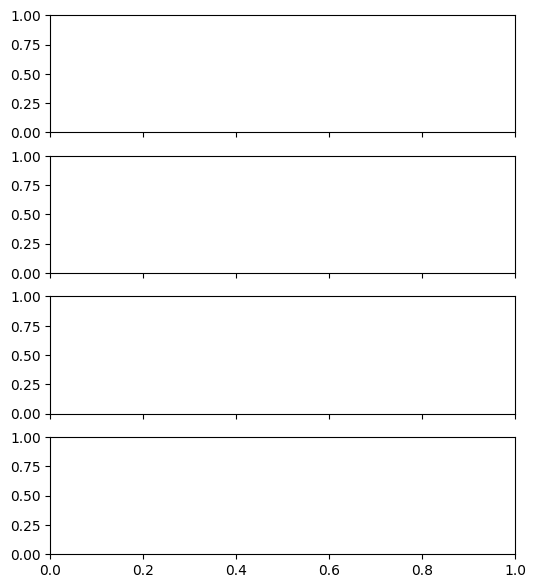

In [23]:
# ── 9.3 — Per-species delta (FPV − Baseline) ─────────────────────────────────
fig, axes = plt.subplots(len(SPECIES_GROUPS), 1, figsize=(6, 7), sharex=True, sharey = True)
panel_letters = list('abcd')
fpv_scens = ['FPV_02', 'FPV_03', 'FPV_04']
for ax, grp, letter in zip(axes, SPECIES_GROUPS, panel_letters):
    base = groups['Baseline'][grp]
    for scen in fpv_scens:
        diff = groups[scen][grp] - base
        ax.plot(diff.index, diff.values, lw=1.2,
                color=SCEN_COLORS[scen], label=scen)
    ax.axhline(0, color='k', lw=0.5, alpha=0.5)
    ax.set_ylabel(f'Δ {grp}\n(gC/m³)', fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.tick_params(labelsize=10)
    add_panel_letter(ax, f'({letter}) {grp}', x=0.02, y=0.95, fontsize=9)

axes[0].legend(fontsize=8, ncol=3, loc='upper right')
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))
axes[-1].xaxis.set_major_locator(mdates.MonthLocator())
# fig.suptitle('Per-species biomass change (FPV − Baseline)', fontsize=11)
plt.tight_layout()
save_fig(fig, '09_3_species_delta')
plt.show()

In [24]:
# ── 9.4 — Monthly species composition bar plots (improved visibility) ──────
groups_monthly = {}
for scen in SCEN_ORDER:
    gm = {}
    for grp_name, ecotypes in SPECIES_GROUPS.items():
        present = [s for s in ecotypes if s in series_daily[scen].columns]
        if present:
            gm[grp_name] = series_daily[scen][present].sum(axis=1).resample('MS').mean()
        else:
            gm[grp_name] = pd.Series(0, index=series_daily[scen].index).resample('MS').mean()
    groups_monthly[scen] = pd.DataFrame(gm)

months = groups_monthly['Baseline'].index
month_labels = [m.strftime('%b\n%Y') for m in months]
n_months = len(months)
n_scen = len(SCEN_ORDER)

SCEN_SHORT = {'Baseline': 'B', 'FPV_02': '02', 'FPV_03': '03', 'FPV_04': '04'}

bar_w = 0.20
fig_w = max(5, n_months * 1.3)


def _draw_grouped_stacked(ax, value_func, ylabel, ylim_top=None):
    """Common drawing routine for absolute and % composition bar charts."""
    x = np.arange(n_months)
    for xi in x[:-1]:
        ax.axvline(xi + 0.5, color='#cccccc', lw=0.5, ls=':', zorder=0)

    for j, scen in enumerate(SCEN_ORDER):
        offset = (j - (n_scen - 1) / 2) * bar_w
        bottom = np.zeros(n_months)
        for grp_name in SPECIES_GROUPS:
            vals = value_func(scen, grp_name)
            ax.bar(x + offset, vals, bar_w,
                   bottom=bottom, color=GROUP_COLORS[grp_name],
                   edgecolor='black', lw=0.4, alpha=0.92,
                   label=grp_name if j == 0 else None)
            bottom = bottom + np.nan_to_num(vals)
        for xi, h in zip(x, bottom):
            ax.annotate(SCEN_SHORT[scen],
                        xy=(xi + offset, h),
                        xytext=(0, 3), textcoords='offset points',
                        ha='center', va='bottom', fontsize=8,
                        color='k', 
                        clip_on=False)

    ax.set_xticks(x)
    ax.set_xticklabels(month_labels, fontsize=10)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.grid(True, axis='y', alpha=0.3, zorder=0)
    ax.tick_params(labelsize=9)
    if ylim_top is not None:
        ax.set_ylim(0, ylim_top)
    else:
        cur_top = ax.get_ylim()[1]
        ax.set_ylim(0, cur_top * 1.20)


# ── Single figure with two stacked panels ────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(fig_w, 5), sharex=True)

# (a) Absolute monthly biomass
_draw_grouped_stacked(
    axes[0],
    value_func=lambda scen, grp: groups_monthly[scen][grp].values,
    ylabel='Biomass (gC/m³)',
)
add_panel_letter(axes[0], '(a)', x=0.02, y=0.95, fontsize=10)

grp_handles = [Patch(facecolor=GROUP_COLORS[g], edgecolor='black', lw=0.4,
                     label=g) for g in SPECIES_GROUPS]
axes[0].legend(handles=grp_handles, fontsize=9, ncol=2,
               loc='upper right', frameon=True)


# (b) Relative monthly composition
def _pct_value(scen, grp):
    total = sum(groups_monthly[scen][g].values for g in SPECIES_GROUPS)
    safe = np.where(total > 0, total, np.nan)
    return groups_monthly[scen][grp].values / safe * 100

_draw_grouped_stacked(
    axes[1],
    value_func=_pct_value,
    ylabel='% biomass',
    ylim_top=115,
)
add_panel_letter(axes[1], '(b)', x=0.02, y=0.95, fontsize=9)

# axes[1].legend(handles=grp_handles, fontsize=9, ncol=4,
#                loc='lower left', frameon=True)

# fig.suptitle('Monthly species composition — all scenarios',
#              fontsize=12, y=0.995)

plt.tight_layout()
save_fig(fig, '09_4_monthly_composition_combined')
plt.show()

<Figure size 650x500 with 2 Axes>

In [25]:
# ── Section 9 — Biomass-weighted limitation (E/N/P ecotypes), 4-scenario ────
# Sum E-, N-, P-adapted ecotypes across Diatoms, Greens, Cyanobacteria;
# Flagellates excluded (no E/N/P split). APHANFIX_F tracked separately.
# Averaging: FPV_02 perimeter mean across active layers K=7..15.

ALL_E = ['FDIATOMS_E', 'GREENS_E',
         'MICROCYS_E', 'APHANFIX_E', 'OSCILAT_E', 'ANABAENA_E']
ALL_N = ['FDIATOMS_N', 'GREENS_N',
         'MICROCYS_N', 'APHANFIX_N', 'OSCILAT_N', 'ANABAENA_N']
ALL_P = ['FDIATOMS_P', 'GREENS_P',
         'MICROCYS_P', 'APHANFIX_P', 'OSCILAT_P', 'ANABAENA_P']
ALL_F = ['APHANFIX_F']

ECOTYPE_COLOURS = {
    'E': '#2ca02c',   # green — energy/light-adapted
    'N': '#1f77b4',   # blue  — N-adapted
    'P': '#d62728',   # red   — P-adapted
    'F': '#9467bd',   # purple — N-fixing free
}
ECOTYPE_LABELS = {
    'E': 'E (energy/light-adapted)',
    'N': 'N (N-adapted)',
    'P': 'P (P-adapted)',
    'F': 'F (N-fixing free)',
}


def perimeter_ecotype_series(ds, perim_da, ecotypes,
                              k_slice=slice(K_TOP, K_BOT)):
    """Sum the listed ecotype substances at each timestep, taking the
    FPV_02-perimeter mean across active layers."""
    total = None
    for sp in ecotypes:
        if sp not in ds.data_vars:
            continue
        da = ds[sp].where(perim_da).sel(K=k_slice).mean(['M', 'N', 'K'])
        s = pd.Series(da.values, index=pd.DatetimeIndex(da.time.values))
        s = s.resample('D').mean()
        total = s if total is None else total.add(s, fill_value=0)
    if total is None:
        return pd.Series(dtype=float)
    return total


def build_perimeter_ecotype_df(ds, perim_da):
    """DataFrame with columns E, N, P, F — perimeter-mean carbon biomass
    by ecotype, summed across all groups, integrated over K=7..15."""
    cols = {}
    cols['E'] = perimeter_ecotype_series(ds, perim_da, ALL_E)
    cols['N'] = perimeter_ecotype_series(ds, perim_da, ALL_N)
    cols['P'] = perimeter_ecotype_series(ds, perim_da, ALL_P)
    cols['F'] = perimeter_ecotype_series(ds, perim_da, ALL_F)
    # Ensure datetime index even when some cols are empty
    ref_idx = None
    for s in cols.values():
        if not s.empty:
            ref_idx = s.index
            break
    if ref_idx is None:
        return pd.DataFrame()
    for k, s in cols.items():
        if s.empty:
            cols[k] = pd.Series(0.0, index=ref_idx)
    df = pd.concat(cols, axis=1).fillna(0)
    df.index = pd.DatetimeIndex(df.index)
    return df


# Build per-scenario DataFrames
ecot_by_scen = {scen: build_perimeter_ecotype_df(runs[scen], perim_da)
                for scen in SCEN_ORDER}

# Decide whether to show the F ecotype anywhere
f_max = max(ecot_by_scen[scen]['F'].max() for scen in SCEN_ORDER)
plot_ecotypes = ['E', 'N', 'P'] + (['F'] if f_max > 1e-6 else [])
print(f'F-ecotype max biomass across scenarios: {f_max:.6g} gC/m³  '
      f'({"included" if f_max > 1e-6 else "skipped — effectively zero"})')


# ── 4-panel grid: one stacked area per scenario ────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(8, 5.5), sharex=True, sharey=True)
axes_flat = axes.flatten()

panel_labels = ['(a)', '(b)', '(c)', '(d)']
for ax, scen, plabel in zip(axes_flat, SCEN_ORDER, panel_labels):
    df = ecot_by_scen[scen]
    stack = [df[e].values for e in plot_ecotypes]
    colours = [ECOTYPE_COLOURS[e] for e in plot_ecotypes]
    labels = [ECOTYPE_LABELS[e] for e in plot_ecotypes]
    ax.stackplot(df.index, stack, labels=labels, colors=colours, alpha=0.85)
    ax.set_title(f'{plabel} {scen}',
                 fontsize=9, loc='left')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.tick_params(labelsize=8)
    ax.grid(True, alpha=0.3)

axes_flat[0].legend(fontsize=7, loc='upper left')

axes_flat[0].set_ylabel('Biomass (gC/m³)', fontsize=9)
axes_flat[2].set_ylabel('Biomass (gC/m³)', fontsize=9)

# fig.suptitle('Biomass-weighted limitation (E/N/P ecotypes) — '
#              'FPV_02 perimeter mean (K=7..15)',
#              fontsize=11, y=1.00)

# fig.text(0.5, -0.005,
#          'Interpretation: dominance of an ecotype indicates which limitation '
#          'regime the standing biomass evolved under.\n'
#          'P-adapted dominance → cells holding high internal P → externally N-limited. '
#          'This is a biomass signature of historical conditions, not the current rate-limit.',
#          ha='center', fontsize=8, color='grey')

plt.tight_layout()
save_fig(fig, '09_ecotype_biomass_all_scenarios')
plt.show()


# ── Monthly mean table ─────────────────────────────────────────────────
print('\nEcotype perimeter-mean biomass — monthly means (gC/m³):')
hdr = f'  {"Scenario":<10} {"Month":<10}'
for e in plot_ecotypes:
    hdr += f'  {ECOTYPE_LABELS[e][:5]:>8}'
print(hdr)
print('  ' + '-' * (24 + 10 * len(plot_ecotypes)))
for scen in SCEN_ORDER:
    monthly = ecot_by_scen[scen].resample('MS').mean()
    for month, row in monthly.iterrows():
        line = f'  {scen:<10} {month.strftime("%Y-%m"):<10}'
        for e in plot_ecotypes:
            line += f'  {row[e]:>8.4f}'
        print(line)
    print()

F-ecotype max biomass across scenarios: 0 gC/m³  (skipped — effectively zero)


<Figure size 800x550 with 4 Axes>


Ecotype perimeter-mean biomass — monthly means (gC/m³):
  Scenario   Month          E (en     N (N-     P (P-
  ------------------------------------------------------
  Baseline   2023-04       0.0393    0.0031    0.0056
  Baseline   2023-05       0.0335    0.0019    0.0004
  Baseline   2023-06       0.0647    0.0010    0.1353
  Baseline   2023-07       0.0626    0.0005    0.0904
  Baseline   2023-08       0.0264    0.0013    0.0052

  FPV_02     2023-04       0.0521    0.0021    0.0066
  FPV_02     2023-05       0.0626    0.0018    0.0057
  FPV_02     2023-06       0.0139    0.0016    0.3670
  FPV_02     2023-07       0.0007    0.0027    0.3308
  FPV_02     2023-08       0.0340    0.0037    0.2221

  FPV_03     2023-04       0.0407    0.0034    0.0056
  FPV_03     2023-05       0.0333    0.0018    0.0005
  FPV_03     2023-06       0.0667    0.0010    0.1281
  FPV_03     2023-07       0.0671    0.0005    0.0821
  FPV_03     2023-08       0.0254    0.0013    0.0052

  FPV_04     2023-0

In [26]:
# ── Section 9 — BLOOM Limit* diagnostics (E/N/P), 4-scenario comparison ────
# Limit nit / Limit pho / Limit e from .his at CAB(8) (surface monitor).
# Important: Limit* substances are NOT in the NetCDF — they're written to
# .his only. The "perimeter mean" convention used elsewhere in this section
# does not apply here. We use the CAB(8) point monitor across all scenarios.
# Values are 0-1; the MINIMUM across N/P/E is the active growth limit.

LIMIT_VARS = {
    'Limit nit':  ('N limitation',      '#1f77b4'),   # blue
    'Limit pho':  ('P limitation',      '#d62728'),   # red
    'Limit e':    ('Light/energy lim.', '#2ca02c'),   # green
}


def his_limit_series_4scen(his_run, var_name, k_label=8):
    """Read a Limit* series at CAB(k_label) from .his. Daily resampled."""
    locs = his_run['locations']
    # Find CAB monitor index for this 1-based k_label
    cab_idx = None
    for li, name in enumerate(locs):
        if name == f'CAB ({k_label})':
            cab_idx = li
            break
    if cab_idx is None:
        return pd.Series(dtype=float)
    si = his_run['idx'].get(var_name)
    if si is None:
        return pd.Series(dtype=float)
    ts = pd.Series(his_run['data'][:, cab_idx, si].astype(float),
                   index=his_run['timestamps'])
    return ts.resample('D').mean()


# Build per-scenario Limit* DataFrames
limit_by_scen = {}
for scen in SCEN_ORDER:
    df = pd.DataFrame({
        v: his_limit_series_4scen(his_runs[scen], v, k_label=8)
        for v in LIMIT_VARS
    })
    df = df.dropna(axis=1, how='all')
    limit_by_scen[scen] = df

# Determine which variables are present in all scenarios
present = sorted(set.intersection(*(set(df.columns) for df in limit_by_scen.values())))
present = [v for v in LIMIT_VARS if v in present]
print(f'Limit* variables present in .his (all scenarios): {present}')


# ── 4-panel grid: one Limit* line plot per scenario ────────────────────
fig, axes = plt.subplots(2, 2, figsize=(7, 5.5), sharex=True, sharey=True)
axes_flat = axes.flatten()

panel_labels = ['(a)', '(b)', '(c)', '(d)']
for ax, scen, plabel in zip(axes_flat, SCEN_ORDER, panel_labels):
    df = limit_by_scen[scen]
    for v in present:
        label, colour = LIMIT_VARS[v]
        ax.plot(df.index, df[v].values, color=colour, lw=1.2, label=label)
    ax.axhline(1, color='k', lw=0.5, ls=':', alpha=0.5)
    ax.set_title(f'{plabel} {scen}',
                 fontsize=9, loc='left')
    ax.set_ylim(0, 1.05)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.tick_params(labelsize=8)
    ax.grid(True, alpha=0.3)
    
axes_flat[0].legend(fontsize=7, loc='lower left')

axes_flat[0].set_ylabel('Limitation factor (0-1)', fontsize=9)
axes_flat[2].set_ylabel('Limitation factor (0-1)', fontsize=9)
# fig.suptitle('BLOOM Limit* diagnostics (E/N/P) — CAB(8) surface monitor',
#              fontsize=11, y=1.00)

# fig.text(0.5, -0.015,
#          'Interpretation: low Limit* values mean strong limitation. The minimum '
#          'across N/P/E is the active rate-limiter at each timestep.\n'
#          'Note: spatial convention differs from other section-9 plots — Limit* is '
#          '.his-only (point monitor), not a NetCDF perimeter mean.',
#          ha='center', fontsize=8, color='grey')

plt.tight_layout()
save_fig(fig, '09_limit_factors_all_scenarios')
plt.show()


# ── Active limiter summary ─────────────────────────────────────────────
print('\nActive growth limiter (most restrictive across N/P/E):')
for scen in SCEN_ORDER:
    df = limit_by_scen[scen]
    if df.empty or not present:
        print(f'  {scen}: no data')
        continue
    active_lim = df[present].idxmin(axis=1)
    share = active_lim.value_counts(normalize=True) * 100
    print(f'  {scen}:')
    for v, pct in share.items():
        label, _ = LIMIT_VARS[v]
        print(f'    {label:<22} {pct:>5.1f}% of timesteps')


# ── Monthly mean table ─────────────────────────────────────────────────
print('\nMonthly mean limitation factors (CAB(8)):')
hdr = f'  {"Scenario":<10} {"Month":<10}'
for v in present:
    label, _ = LIMIT_VARS[v]
    hdr += f'  {label[:6]:>8}'
print(hdr)
print('  ' + '-' * (24 + 10 * len(present)))
for scen in SCEN_ORDER:
    df = limit_by_scen[scen].copy()
    if df.empty:
        continue
    df.index = pd.to_datetime(df.index)
    monthly = df.resample('MS').mean()
    for month, row in monthly.iterrows():
        line = f'  {scen:<10} {month.strftime("%Y-%m"):<10}'
        for v in present:
            line += f'  {row[v]:>8.4f}'
        print(line)
    print()

Limit* variables present in .his (all scenarios): ['Limit nit', 'Limit pho', 'Limit e']


<Figure size 700x550 with 4 Axes>


Active growth limiter (most restrictive across N/P/E):
  Baseline:
    N limitation           100.0% of timesteps
  FPV_02:
    N limitation           100.0% of timesteps
  FPV_03:
    N limitation           100.0% of timesteps
  FPV_04:
    N limitation           100.0% of timesteps

Monthly mean limitation factors (CAB(8)):
  Scenario   Month         N limi    P limi    Light/
  ------------------------------------------------------
  Baseline   2023-04       0.0000    0.0000    0.0000
  Baseline   2023-05       0.0000    0.0000    0.0000
  Baseline   2023-06       0.0000    0.6667    0.0000
  Baseline   2023-07       0.0000    0.6452    0.0000
  Baseline   2023-08       0.0000    0.0000    0.0000

  FPV_02     2023-04       0.0000    0.0000    0.0000
  FPV_02     2023-05       0.0000    0.0645    0.0000
  FPV_02     2023-06       0.0000    1.0000    0.0000
  FPV_02     2023-07       0.0000    1.0000    0.0000
  FPV_02     2023-08       0.0000    0.8710    0.0000

  FPV_03     2023-

In [27]:
# ── Ecotype carbon biomass — Baseline vs FPV_02, FPV perimeter mean ─────
# Sum carbon biomass across all algae species by ecotype letter (_E/_N/_P/_F).
# Same approach as Section 14 of the diagnostic notebook, but perimeter-
# averaged across the FPV array footprint instead of CAB-point.

ECOTYPE_SUFFIXES = {
    'E (light-adapted)':       '_E',
    'N (N-adapted)':           '_N',
    'P (P-adapted)':           '_P',
    'F (N-fixing)':            '_F',
}
ECOTYPE_COLOURS = {
    'E (light-adapted)': '#2ca02c',   # green
    'N (N-adapted)':     '#1f77b4',   # blue
    'P (P-adapted)':     '#d62728',   # red
    'F (N-fixing)':      '#9467bd',   # purple
}

# Flagellates have no suffix — treat as E by convention (light-adapted only)
EXTRA_E_SPECIES = ['FFLAGELA']


def sum_ecotype_perim(series_dict, scen, suffix):
    """Sum all columns in series_daily[scen] whose name ends with `suffix`."""
    cols = [c for c in series_dict[scen].columns if c.endswith(suffix)]
    if suffix == '_E':
        cols += [c for c in EXTRA_E_SPECIES if c in series_dict[scen].columns]
    if not cols:
        return pd.Series(dtype=float)
    return series_dict[scen][cols].sum(axis=1)


# Build ecotype biomass per scenario
ecotype_biomass = {}
for scen in ['Baseline', 'FPV_02']:
    ecotype_biomass[scen] = {}
    for label, suffix in ECOTYPE_SUFFIXES.items():
        ecotype_biomass[scen][label] = sum_ecotype_perim(
            series_daily_surf, scen, suffix)


# ── Plot: 3 panels, sharing x-axis ──────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(11, 3.5))
# Share y between panels (a) and (b) — they show absolute biomass on the
# same units, so direct visual comparison benefits from a common scale.
axes[1].sharey(axes[0])
plt.setp(axes[1].get_yticklabels(), visible=False)

# Panel (a) Baseline — stacked
ax = axes[0]
stack_b = []
labels = []
for label in ECOTYPE_SUFFIXES.keys():
    series = ecotype_biomass['Baseline'][label]
    if series.empty:
        continue
    stack_b.append(series.values)
    labels.append(label)
times_b = ecotype_biomass['Baseline'][list(ECOTYPE_SUFFIXES.keys())[0]].index
colours_b = [ECOTYPE_COLOURS[lab] for lab in labels]
ax.stackplot(times_b, *stack_b, labels=labels, colors=colours_b, alpha=0.85)
ax.set_ylabel('Biomass (gC/m³)', fontsize=10)
ax.set_title('(a) Baseline — ecotype carbon biomass', fontsize=10, loc='left')
ax.legend(fontsize=9, loc='upper left')
ax.tick_params(labelsize=9)
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator())

# Panel (b) FPV_02 — stacked
ax = axes[1]
stack_f = []
for label in ECOTYPE_SUFFIXES.keys():
    series = ecotype_biomass['FPV_02'][label]
    if series.empty:
        continue
    stack_f.append(series.values)
times_f = ecotype_biomass['FPV_02'][list(ECOTYPE_SUFFIXES.keys())[0]].index
ax.stackplot(times_f, *stack_f, labels=labels, colors=colours_b, alpha=0.85)
ax.set_title('(b) FPV — ecotype carbon biomass', fontsize=10, loc='left')
ax.tick_params(labelsize=9)
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator())

# Panel (c) Δ (FPV − Baseline) — lines, per ecotype
ax = axes[2]
common_idx = ecotype_biomass['Baseline'][labels[0]].index.intersection(
    ecotype_biomass['FPV_02'][labels[0]].index)
for label in labels:
    base = ecotype_biomass['Baseline'][label].loc[common_idx]
    fpv  = ecotype_biomass['FPV_02'][label].loc[common_idx]
    diff = fpv - base
    ax.plot(diff.index, diff.values, color=ECOTYPE_COLOURS[label],
            lw=1.3, label=label)
ax.axhline(0, color='k', lw=0.7, ls='--', alpha=0.5)
ax.set_ylabel('Δ FPV − Baseline (gC/m³)', fontsize=10)
ax.set_title('(c) Δ ecotype biomass (FPV − Baseline)',
             fontsize=10, loc='left')
ax.tick_params(labelsize=9)
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator())

# Common x-limit
for ax in axes:
    ax.set_xlim(pd.Timestamp('2023-04-01'), pd.Timestamp('2023-08-31'))

plt.tight_layout()

# AFTER tight_layout settles, override panel (b)'s position
fig.subplots_adjust(left=0.05, right=0.98, top=0.92, bottom=0.12,
                    wspace=0.15)
pos_a = axes[0].get_position()
pos_b = axes[1].get_position()
axes[1].set_position([pos_a.x0 + pos_a.width + 0.01,
                      pos_b.y0, pos_b.width, pos_b.height])

save_fig(fig, '09_ecotype_biomass_baseline_vs_fpv02')
plt.show()

# Print summary stats
print('\nEcotype biomass summary — perimeter mean, Apr-Aug 2023:')
print(f'  {"Ecotype":<22} {"Baseline mean":>14} {"FPV_02 mean":>14} '
      f'{"Δ abs":>10} {"Δ %":>10}')
print('  ' + '-' * 80)
for label in labels:
    bm = ecotype_biomass['Baseline'][label].mean()
    fm = ecotype_biomass['FPV_02'][label].mean()
    d_abs = fm - bm
    d_pct = (d_abs / bm * 100) if bm != 0 else np.nan
    print(f'  {label:<22} {bm:>14.4f} {fm:>14.4f} '
          f'{d_abs:>+10.4f} {d_pct:>+9.2f}%')

<Figure size 1100x350 with 3 Axes>


Ecotype biomass summary — perimeter mean, Apr-Aug 2023:
  Ecotype                 Baseline mean    FPV_02 mean      Δ abs        Δ %
  --------------------------------------------------------------------------------
  E (light-adapted)              0.1539         0.0931    -0.0608    -39.50%
  N (N-adapted)                  0.0121         0.0185    +0.0064    +52.72%
  P (P-adapted)                  0.1691         0.5786    +0.4095   +242.15%


In [28]:
# Check 1: Is total carbon biomass higher under FPV, or just Chla?
b_biomass_jul = series_daily_surf['Baseline']['TotAlgae'].loc['2023-07'].mean()
f_biomass_jul = series_daily_surf['FPV_02']['TotAlgae'].loc['2023-07'].mean()
b_chla_jul    = series_daily_surf['Baseline']['Chlfa'].loc['2023-07'].mean()
f_chla_jul    = series_daily_surf['FPV_02']['Chlfa'].loc['2023-07'].mean()
print(f'July surface biomass (gC/m³): Baseline={b_biomass_jul:.3f}, '
      f'FPV={f_biomass_jul:.3f}, ratio={f_biomass_jul/b_biomass_jul:.2f}')
print(f'July surface Chla (µg/L):     Baseline={b_chla_jul:.3f}, '
      f'FPV={f_chla_jul:.3f}, ratio={f_chla_jul/b_chla_jul:.2f}')

July surface biomass (gC/m³): Baseline=0.555, FPV=1.037, ratio=1.87
July surface Chla (µg/L):     Baseline=13.959, FPV=25.911, ratio=1.86


In [29]:
# Check 2: Species composition shift — what fraction of biomass is P-adapted?
date_range = slice('2023-07-01', '2023-07-31')
for scen in ['Baseline', 'FPV_02']:
    df = series_daily_surf[scen].loc[date_range]
    e_total = df[[c for c in df.columns if c.endswith('_E')]].sum(axis=1).mean()
    n_total = df[[c for c in df.columns if c.endswith('_N')]].sum(axis=1).mean()
    p_total = df[[c for c in df.columns if c.endswith('_P')]].sum(axis=1).mean()
    total = e_total + n_total + p_total
    print(f'{scen}:')
    print(f'  E (light-adapted): {e_total:.3f} ({e_total/total*100:.0f}%)')
    print(f'  N (N-adapted):     {n_total:.3f} ({n_total/total*100:.0f}%)')
    print(f'  P (P-adapted):     {p_total:.3f} ({p_total/total*100:.0f}%)')

Baseline:
  E (light-adapted): 0.207 (39%)
  N (N-adapted):     0.004 (1%)
  P (P-adapted):     0.319 (60%)
FPV_02:
  E (light-adapted): 0.004 (0%)
  N (N-adapted):     0.021 (2%)
  P (P-adapted):     1.011 (98%)


In [30]:
# Check 3: Depth-averaged biomass — is the column-integrated effect smaller?
b_biomass_davg = series_daily['Baseline']['TotAlgae'].loc['2023-07'].mean()
f_biomass_davg = series_daily['FPV_02']['TotAlgae'].loc['2023-07'].mean()
print(f'Depth-avg July biomass (gC/m³): Baseline={b_biomass_davg:.3f}, '
      f'FPV={f_biomass_davg:.3f}, '
      f'ratio={f_biomass_davg/b_biomass_davg:.2f}')

Depth-avg July biomass (gC/m³): Baseline=0.161, FPV=0.335, ratio=2.08


## Section 10 — Depth profiles (perimeter-averaged Hovmöller)

For each substance: a four-panel figure of time × depth Hovmöllers per
scenario, plus three FPV − Baseline difference panels. Computed directly
via xarray: `ds[sub].where(perim_da).mean(['M', 'N'])` over the K=K_TOP..K_BOT
range.

In [31]:
# Use the canonical substance list from series_daily (which has the full set)
DERIVED = {'TotN', 'TotP', 'TotAlgae', 'Chlfa'}
direct_subs = [s for s in series_daily['Baseline'].columns if s not in DERIVED]
print(f'Building depth profiles for {len(direct_subs)} substances')

def compute_depth_profile(ds, substance, perim_da):
    """Build (T, K_ACTIVE) time × layer matrix, perimeter-averaged per layer."""
    if substance not in ds:
        return None
    da = ds[substance].sel(K=slice(K_TOP, K_BOT)).where(perim_da)
    if substance == 'OXY':
        da = da.where(da <= OXY_MAX_PHYS)
    # Mean over M and N at each (time, K) — collapses spatial dims
    da = da.mean(['M', 'N'])
    # Daily resample after spatial reduction (cheap once spatial is collapsed)
    da = da.resample(time='D').mean()
    return da

print('Computing depth profiles per substance per scenario...')
depth_profiles = {}
for scen, ds in runs.items():
    print(f'  {scen}...')
    depth_profiles[scen] = {}
    for sub in direct_subs:
        prof = compute_depth_profile(ds, sub, perim_da)
        if prof is not None:
            depth_profiles[scen][sub] = prof

# Reconstructed Chlfa per layer
print('\nReconstructing Chlfa depth profiles...')
chlfa_profiles = {}
for scen in SCEN_ORDER:
    chlfa_da = None
    for sp, ratio in CHLA_C.items():
        if sp not in depth_profiles[scen]:
            continue
        contrib = depth_profiles[scen][sp] * ratio * 1000.0
        chlfa_da = contrib if chlfa_da is None else (chlfa_da.fillna(0) + contrib.fillna(0))
    chlfa_profiles[scen] = chlfa_da
print('Done.')

Building depth profiles for 25 substances
Computing depth profiles per substance per scenario...
  Baseline...
  FPV_02...
  FPV_03...
  FPV_04...

Reconstructing Chlfa depth profiles...
Done.


In [ ]:
def plot_depth_panel_grid(profiles, substance, surface_mid_series=None,
                          cmap='viridis', diff_cmap='RdBu_r', save_name=None):
    """One figure: top row absolute (4 scenarios), bottom row 3 diffs.
    Panel letters (a)-(g) annotate each panel; scenario name added to top-left
    text. Substance shown only in suptitle and colorbars."""
    if substance not in profiles['Baseline'] or profiles['Baseline'][substance] is None:
        print(f'  skip {substance}: not in profiles')
        return

    prof_base = profiles['Baseline'][substance]
    times_b = pd.DatetimeIndex(prof_base.time.values)
    k_range = list(prof_base.K.values)

    prof_by_scen = {scen: profiles[scen][substance].values for scen in SCEN_ORDER}

    all_vals = np.concatenate([p[~np.isnan(p)] for p in prof_by_scen.values()])
    if all_vals.size == 0:
        print(f'  skip {substance}: no valid data'); return
    vmin, vmax = np.nanpercentile(all_vals, [2, 98])

    p50 = np.nanpercentile(all_vals, 50)
    rng = vmax - vmin
    skew = abs((p50 - (vmin + vmax) / 2) / rng) if rng > 0 else 0
    if skew > 0.35 and vmax > 0 and vmin >= 0:
        linthresh = max(vmax * 1e-3, 1e-9)
        norm = SymLogNorm(linthresh=linthresh, vmin=vmin, vmax=vmax, base=10)
    else:
        norm = Normalize(vmin=vmin, vmax=vmax)

    thicknesses = np.array([THICKNESS_M[k] for k in k_range])
    d_edges = np.zeros(len(k_range) + 1)
    for i in range(len(k_range)):
        d_edges[i + 1] = d_edges[i] + thicknesses[i]

    t_num = mdates.date2num(times_b.to_pydatetime())
    if len(t_num) > 1:
        dt = t_num[1] - t_num[0]
        t_edges = np.concatenate([t_num - dt/2, [t_num[-1] + dt/2]])
    else:
        t_edges = np.array([t_num[0] - 0.5, t_num[0] + 0.5])

    base_vals = prof_by_scen['Baseline']
    diffs = {scen: prof_by_scen[scen] - base_vals
             for scen in ['FPV_02', 'FPV_03', 'FPV_04']}
    diff_vals = np.concatenate([d[~np.isnan(d)] for d in diffs.values()])
    dlim = np.nanpercentile(np.abs(diff_vals), 98) if diff_vals.size else 1.0

    cm_main = plt.get_cmap(cmap).copy();      cm_main.set_bad('#dddddd')
    cm_diff = plt.get_cmap(diff_cmap).copy(); cm_diff.set_bad('#dddddd')

    display_label = label_for(substance)

    fig, axes = plt.subplots(2, 4, figsize=(9, 5), sharex=True, sharey=True)

    panel_letters = list('abcdefgh')
    # Top row: absolute (a, b, c, d)
    for ax, scen, letter in zip(axes[0], SCEN_ORDER, panel_letters[:4]):
        prof = prof_by_scen[scen]
        pc = ax.pcolormesh(t_edges, d_edges, np.ma.masked_invalid(prof.T),
                           cmap=cm_main, norm=norm, shading='flat')
        if surface_mid_series is not None:
            ax.plot(mdates.date2num(surface_mid_series.index.to_pydatetime()),
                    surface_mid_series.values, color='black', lw=0.7, alpha=0.85)
        ax.invert_yaxis()
        ax.tick_params(labelsize=8)
        add_panel_letter(ax, f'({letter}) {scen}', x=0.02, y=0.97, fontsize=9)
    axes[0, 0].set_ylabel('Depth (m)', fontsize=10)
    cbar_ax = fig.add_axes([0.92, 0.55, 0.012, 0.32])
    fig.colorbar(pc, cax=cbar_ax, label=display_label)

    # Bottom row: differences (e, f, g) — leftmost slot stays empty
    # Bottom row: differences (e, f, g) — leftmost slot stays empty
    axes[1, 0].set_visible(False)
    diff_letters = panel_letters[4:7]
    bottom_axes = [axes[1, 1], axes[1, 2], axes[1, 3]]
    for ax, scen, letter in zip(bottom_axes, ['FPV_02', 'FPV_03', 'FPV_04'],
                                 diff_letters):
        d = diffs[scen]
        pcd = ax.pcolormesh(t_edges, d_edges, np.ma.masked_invalid(d.T),
                            cmap=cm_diff, vmin=-dlim, vmax=dlim, shading='flat')
        if surface_mid_series is not None:
            ax.plot(mdates.date2num(surface_mid_series.index.to_pydatetime()),
                    surface_mid_series.values, color='black', lw=0.7, alpha=0.85)
        ax.invert_yaxis()
        ax.tick_params(labelsize=8)
        add_panel_letter(ax, f'({letter}) Δ ({scen} − Baseline)',
                         x=0.02, y=0.1, fontsize=9)
    
    # Show y-tick labels ONLY on the leftmost bottom panel (panel e = axes[1, 1])
    bottom_axes[0].tick_params(labelleft=True)
    bottom_axes[0].set_ylabel('Depth (m)', fontsize=10)
    cbar_ax2 = fig.add_axes([0.92, 0.12, 0.012, 0.32])
    fig.colorbar(pcd, cax=cbar_ax2, label=f'Δ {display_label}')

    for ax in axes[1, :]:
        if ax.get_visible():
            ax.xaxis_date()
            ax.xaxis.set_major_locator(mdates.MonthLocator())
            ax.xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))

    # Reduced hspace from 0.30 → 0.12 to tighten gap between rows
    plt.subplots_adjust(left=0.05, right=0.90, top=0.88, bottom=0.10,
                        hspace=0.12, wspace=0.10)
    if save_name:
        save_fig(fig, save_name)
    plt.show()


# Build per-species-group depth profiles (sum all ecotypes per group)
SPECIES_ECOTYPES_DEPTH = {
    'Diatoms':       ['FDIATOMS_E', 'FDIATOMS_N', 'FDIATOMS_P'],
    'Greens':        ['GREENS_E',   'GREENS_N',   'GREENS_P'],
    'Flagellates':   ['FFLAGELA'],
    'Cyanobacteria': ['MICROCYS_E', 'MICROCYS_N', 'MICROCYS_P'],
}

print('Building per-species-group depth profiles (summing across ecotypes)...')
group_profiles = {scen: {} for scen in SCEN_ORDER}
for group_name, ecotypes in SPECIES_ECOTYPES_DEPTH.items():
    for scen in SCEN_ORDER:
        present = [s for s in ecotypes if s in depth_profiles[scen]]
        if not present:
            print(f'  {scen} | {group_name}: no ecotypes available, skipping')
            continue
        # Sum the (time, K) profiles across ecotypes
        summed = sum(depth_profiles[scen][s].fillna(0) for s in present)
        group_profiles[scen][group_name] = summed
print('Done.')

# Plot the individual substances (non-algae state variables)
NON_ALGAE_SUBS = [s for s in SUBSTANCES
                  if s not in sum(SPECIES_ECOTYPES_DEPTH.values(), [])]
print(f'\nPlotting depth profiles for {len(NON_ALGAE_SUBS)} non-algae substances...')
for sub in NON_ALGAE_SUBS:
    plot_depth_panel_grid(depth_profiles, sub,
                          surface_mid_series=surface_mid_depth_series,
                          save_name=f'10_depth_{sub}')

# Plot the aggregated species groups
print(f'\nPlotting depth profiles for {len(SPECIES_ECOTYPES_DEPTH)} species groups...')
for group_name in SPECIES_ECOTYPES_DEPTH:
    plot_depth_panel_grid(group_profiles, group_name,
                          cmap='YlGn',
                          surface_mid_series=surface_mid_depth_series,
                          save_name=f'10_depth_{group_name}')

# Reconstructed Chlfa (unchanged)
chlfa_pseudo = {scen: {'Chlfa': chlfa_profiles[scen]} for scen in SCEN_ORDER}
plot_depth_panel_grid(chlfa_pseudo, 'Chlfa',
                      cmap='YlGn',
                      surface_mid_series=surface_mid_depth_series,
                      save_name='10_depth_Chlfa')

Building per-species-group depth profiles (summing across ecotypes)...
Done.

Plotting depth profiles for 8 non-algae substances...


<Figure size 900x500 with 10 Axes>

<Figure size 900x500 with 10 Axes>

<Figure size 900x500 with 10 Axes>

In [ ]:
# ── Single-substance Baseline vs FPV_02 depth profile (3-panel) ──────────
# Mirrors the DO depth-profile layout from the diagnostic notebook:
# (a) Baseline, (b) FPV_02, (c) Δ — all sharing y-axis, two shared colorbars.

def plot_depth_panel_3col(profiles, substance, scenario='FPV_02',
                           cmap='viridis', diff_cmap='RdBu_r',
                           save_name=None,
                           surface_mid_series=None):
    """Single-substance 3-panel depth-time figure: Baseline | Scenario | Δ."""
    if (substance not in profiles['Baseline']
            or profiles['Baseline'][substance] is None
            or substance not in profiles[scenario]
            or profiles[scenario][substance] is None):
        print(f'  skip {substance}: not in both Baseline and {scenario}'); return

    prof_B = profiles['Baseline'][substance]
    prof_S = profiles[scenario][substance]
    times_b = pd.DatetimeIndex(prof_B.time.values)
    k_range = list(prof_B.K.values)

    base_vals = prof_B.values
    scen_vals = prof_S.values
    diff_vals = scen_vals - base_vals

    # Pooled colour range across Baseline + scenario (absolute panels)
    all_abs = np.concatenate([
        base_vals[~np.isnan(base_vals)],
        scen_vals[~np.isnan(scen_vals)],
    ])
    if all_abs.size == 0:
        print(f'  skip {substance}: no valid data'); return
    vmin, vmax = np.nanpercentile(all_abs, [2, 98])

    # Auto-detect skew → SymLog (same heuristic as the 4-scenario grid)
    p50 = np.nanpercentile(all_abs, 50)
    rng = vmax - vmin
    skew = abs((p50 - (vmin + vmax) / 2) / rng) if rng > 0 else 0
    if skew > 0.35 and vmax > 0 and vmin >= 0:
        linthresh = max(vmax * 1e-3, 1e-9)
        norm = SymLogNorm(linthresh=linthresh, vmin=vmin, vmax=vmax, base=10)
    else:
        norm = Normalize(vmin=vmin, vmax=vmax)

    # Difference range — symmetric 98%
    dvalid = diff_vals[~np.isnan(diff_vals)]
    dlim = np.nanpercentile(np.abs(dvalid), 98) if dvalid.size else 1.0

    # Depth edges (consistent with the 4-scenario grid)
    thicknesses = np.array([THICKNESS_M[k] for k in k_range])
    d_edges = np.zeros(len(k_range) + 1)
    for i in range(len(k_range)):
        d_edges[i + 1] = d_edges[i] + thicknesses[i]

    # Time edges
    t_num = mdates.date2num(times_b.to_pydatetime())
    if len(t_num) > 1:
        dt = t_num[1] - t_num[0]
        t_edges = np.concatenate([t_num - dt/2, [t_num[-1] + dt/2]])
    else:
        t_edges = np.array([t_num[0] - 0.5, t_num[0] + 0.5])

    cm_main = plt.get_cmap(cmap).copy();      cm_main.set_bad('#dddddd')
    cm_diff = plt.get_cmap(diff_cmap).copy(); cm_diff.set_bad('#dddddd')

    display_label = label_for(substance)

    # ── Build figure: 3 panels in a row, shared y ───────────────────────
    fig, axes = plt.subplots(1, 3, figsize=(9, 3), sharey=True)

    # Panel (a) Baseline
    pc_abs = axes[0].pcolormesh(t_edges, d_edges,
                                  np.ma.masked_invalid(base_vals.T),
                                  cmap=cm_main, norm=norm, shading='flat')
    axes[0].invert_yaxis()
    axes[0].set_ylabel('Depth (m)', fontsize=9)
    axes[0].tick_params(labelsize=8)

    # Panel (b) Scenario
    axes[1].pcolormesh(t_edges, d_edges,
                        np.ma.masked_invalid(scen_vals.T),
                        cmap=cm_main, norm=norm, shading='flat')
    axes[1].invert_yaxis()
    axes[1].tick_params(labelsize=8)

    # Panel (c) Δ
    pc_diff = axes[2].pcolormesh(t_edges, d_edges,
                                   np.ma.masked_invalid(diff_vals.T),
                                   cmap=cm_diff, vmin=-dlim, vmax=dlim,
                                   shading='flat')
    axes[2].invert_yaxis()
    axes[2].tick_params(labelsize=8)

    # Optional black surface-mid line overlay
    if surface_mid_series is not None:
        smt = mdates.date2num(surface_mid_series.index.to_pydatetime())
        for ax in axes:
            ax.plot(smt, surface_mid_series.values,
                    color='black', lw=0.7, alpha=0.85)

    # X-axis date formatting on all panels
    for ax in axes:
        ax.xaxis_date()
        ax.xaxis.set_major_locator(mdates.MonthLocator())
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))

    # Panel letters
    axes[0].text(0.02, 0.08, '(a) Baseline', transform=axes[0].transAxes,
                  fontsize=9, ha='left', va='top',
                  bbox=dict(facecolor='white', edgecolor='none',
                            pad=2.0, alpha=0.85))
    axes[1].text(0.02, 0.08, f'(b) {scenario}', transform=axes[1].transAxes,
                  fontsize=9, ha='left', va='top',
                  bbox=dict(facecolor='white', edgecolor='none',
                            pad=2.0, alpha=0.85))
    axes[2].text(0.02, 0.08, f'(c) Δ ({scenario} − Baseline)',
                  transform=axes[2].transAxes, fontsize=9, ha='left', va='top',
                  bbox=dict(facecolor='white', edgecolor='none',
                            pad=2.0, alpha=0.85))

    # Two shared colorbars — same layout as the DO diagnostic
    fig.subplots_adjust(left=0.06, right=0.86, top=0.95, bottom=0.18,
                        wspace=0.05)
    cbar_ax_abs  = fig.add_axes([0.87, 0.18, 0.012, 0.77])
    fig.colorbar(pc_abs, cax=cbar_ax_abs, label=display_label)
    cbar_ax_diff = fig.add_axes([0.96, 0.18, 0.012, 0.77])
    fig.colorbar(pc_diff, cax=cbar_ax_diff,
                 label=f'Δ {display_label}\n({scenario} − Baseline)')

    if save_name:
        save_fig(fig, save_name)
    plt.show()


# Reconstructed Chlfa — Baseline vs FPV_02 only
plot_depth_panel_3col(chlfa_pseudo, 'Chlfa', scenario='FPV_02',
                       cmap='YlGn',
                       surface_mid_series=surface_mid_depth_series,
                       save_name='10_depth_Chlfa_baseline_vs_fpv02')

In [ ]:
# Get radiation values at ALL FPV-affected cells, pooled across time
b_at_fpv = rad['noFPV'][:, covered_surf_segs]   # (time, n_fpv_cells)
f_at_fpv = rad['02'][:, covered_surf_segs]

# Mean attenuation across all cells, all timesteps
overall_atten = (1 - f_at_fpv.mean() / b_at_fpv.mean()) * 100
print(f'Mean radiation attenuation across all 622 cells: {overall_atten:.1f}%')

# Distribution of per-cell attenuation (averaged over time)
per_cell_atten = (1 - f_at_fpv.mean(axis=0) / b_at_fpv.mean(axis=0)) * 100
print(f'Per-cell attenuation percentiles:')
print(f'  5th:   {np.percentile(per_cell_atten, 5):.1f}%')
print(f'  25th:  {np.percentile(per_cell_atten, 25):.1f}%')
print(f'  Median: {np.percentile(per_cell_atten, 50):.1f}%')
print(f'  75th:  {np.percentile(per_cell_atten, 75):.1f}%')
print(f'  95th:  {np.percentile(per_cell_atten, 95):.1f}%')
print(f'  Max:   {per_cell_atten.max():.1f}%')

In [35]:
# Where in the water column is the FPV-increased biomass actually accumulating?
print('Biomass at each depth (gC/m³), July mean:')
for k in range(K_TOP, K_BOT + 1):
    b_k = (runs['Baseline']['FDIATOMS_E'] + runs['Baseline']['GREENS_E'] + 
           runs['Baseline']['MICROCYS_E'] + runs['Baseline']['FDIATOMS_P'] +
           runs['Baseline']['GREENS_P'] + runs['Baseline']['MICROCYS_P'])
    f_k = (runs['FPV_02']['FDIATOMS_E'] + runs['FPV_02']['GREENS_E'] +
           runs['FPV_02']['MICROCYS_E'] + runs['FPV_02']['FDIATOMS_P'] +
           runs['FPV_02']['GREENS_P'] + runs['FPV_02']['MICROCYS_P'])
    b_val = b_k.where(perim_da).sel(K=k).mean(['M','N']).resample(time='D').mean().loc['2023-07'].mean().values
    f_val = f_k.where(perim_da).sel(K=k).mean(['M','N']).resample(time='D').mean().loc['2023-07'].mean().values
    print(f'  K={k}: Baseline={float(b_val):.3f}, FPV={float(f_val):.3f}, '
          f'ratio={float(f_val)/float(b_val):.2f}')

  K=8: Baseline=0.206, FPV=0.543, ratio=2.64
  K=9: Baseline=0.198, FPV=0.522, ratio=2.63
  K=10: Baseline=0.163, FPV=0.350, ratio=2.14
  K=11: Baseline=0.097, FPV=0.170, ratio=1.75
  K=12: Baseline=0.046, FPV=0.081, ratio=1.78
  K=13: Baseline=0.019, FPV=0.037, ratio=1.93
  K=14: Baseline=0.007, FPV=0.016, ratio=2.29
  K=15: Baseline=0.003, FPV=0.007, ratio=2.84


    



    
    



    
    



    
    



    
    



    
    



    
    



    
    



    
    



    
    



    
    



    
    



    
    


## Section 11 — Surface maps (snapshot dates)

For each substance × each snapshot date: four-panel figure of K=K_TOP (active
surface) across baseline + 3 FPV runs, plus difference maps below.

In [43]:
import matplotlib.gridspec as gridspec

# Species groups (sum across all ecotypes per group)
SPECIES_ECOTYPES_MAP = {
    'Diatoms':       ['FDIATOMS_E', 'FDIATOMS_N', 'FDIATOMS_P'],
    'Greens':        ['GREENS_E',   'GREENS_N',   'GREENS_P'],
    'Flagellates':   ['FFLAGELA'],
    'Cyanobacteria': ['MICROCYS_E', 'MICROCYS_N', 'MICROCYS_P'],
}


def get_surface_field_at_date(ds, substance, target_date):
    """Get surface (K=K_TOP) field as a daily mean on the target date.
    Handles substance keys that are species groups (sum ecotypes) or direct
    substance names."""
    if substance in SPECIES_ECOTYPES_MAP:
        # Aggregate across all ecotypes in the group
        ecotypes = SPECIES_ECOTYPES_MAP[substance]
        present = [s for s in ecotypes if s in ds.data_vars]
        if not present:
            return None
        da = sum(ds[s].sel(K=K_TOP) for s in present)
    else:
        if substance not in ds.data_vars:
            return None
        da = ds[substance].sel(K=K_TOP)

    # Daily-average then pick the target date
    da = da.resample(time='D').mean()
    da = da.sel(time=target_date, method='nearest')

    if substance == 'OXY':
        da = da.where(da <= OXY_MAX_PHYS)
    return da


def plot_surface_maps_at_date(runs, substance, date_str,
                              cmap='viridis', diff_cmap='RdBu_r',
                              save_name=None):
    """Plot surface maps for one substance × one snapshot date.
    Top row: absolute values per scenario (a-d).
    Bottom row: FPV − Baseline difference panels (e-g).
    Daily-averaged; species substances are summed across ecotypes."""
    target = pd.Timestamp(date_str)
    panels = []
    for scen in SCEN_ORDER:
        da = get_surface_field_at_date(runs[scen], substance, target)
        if da is None:
            print(f'{substance} not in {scen}'); return
        panels.append((scen, da.values, pd.Timestamp(da.time.values)))

    base_name, base_surf, t_actual = panels[0]
    n_runs = len(panels)
    display_label = label_for(substance)

    all_v = np.concatenate([p[1][~np.isnan(p[1])] for p in panels])
    if all_v.size == 0:
        print(f'No valid surface data for {substance} on {date_str}')
        return
    vmin, vmax = np.nanpercentile(all_v, [2, 98])
    cm = plt.get_cmap(cmap).copy(); cm.set_bad('#dddddd')
    cm_d = plt.get_cmap(diff_cmap).copy(); cm_d.set_bad('#dddddd')

    diffs = [p[1] - base_surf for p in panels[1:]]
    diff_vals = np.concatenate([d[~np.isnan(d)] for d in diffs])
    has_diffs = diff_vals.size > 0
    dlim = np.nanpercentile(np.abs(diff_vals), 98) if has_diffs else 1.0

    fig = plt.figure(figsize=(3.5 * n_runs + 1.5, 6.5))
    gs = gridspec.GridSpec(
        2, n_runs + 1, figure=fig,
        width_ratios=[1] * n_runs + [0.06],
        height_ratios=[1, 1],
        wspace=0.20, hspace=0.20,
    )

    panel_letters = list('abcdefgh')

    im_abs = None
    for j, ((name, surf, ts), letter) in enumerate(zip(panels, panel_letters[:4])):
        ax = fig.add_subplot(gs[0, j])
        im_abs = ax.pcolormesh(np.ma.masked_invalid(surf.T),
                               cmap=cm, vmin=vmin, vmax=vmax)
        ax.set_aspect('equal'); ax.tick_params(labelsize=7)
        add_panel_letter(ax, f'({letter}) {name}  {ts.date()}',
                         x=0.02, y=0.97, fontsize=9)

    im_diff = None
    diff_letters = panel_letters[4:7]
    for j, ((name, _, _), letter) in enumerate(zip(panels[1:], diff_letters),
                                                 start=1):
        ax = fig.add_subplot(gs[1, j])
        diff = panels[j][1] - base_surf
        im_diff = ax.pcolormesh(np.ma.masked_invalid(diff.T),
                                cmap=cm_d, vmin=-dlim, vmax=dlim)
        ax.set_aspect('equal'); ax.tick_params(labelsize=7)
        add_panel_letter(ax,
                         f'({letter}) Δ({name} − {base_name})',
                         x=0.02, y=0.97, fontsize=8)

    cax_abs = fig.add_subplot(gs[0, -1])
    fig.colorbar(im_abs, cax=cax_abs, label=display_label)
    if im_diff is not None:
        cax_diff = fig.add_subplot(gs[1, -1])
        fig.colorbar(im_diff, cax=cax_diff,
                     label=f'Δ(FPV scen − Baseline)')

    # fig.suptitle(f'{display_label} — surface (K={K_TOP}) — {t_actual.date()}',
    #              fontsize=12, y=0.98)

    if save_name:
        save_fig(fig, save_name)
    plt.show()


# Build list of substances to plot: non-algae (individual) + species groups
NON_ALGAE_SUBS = [s for s in SUBSTANCES
                  if s not in sum(SPECIES_ECOTYPES_MAP.values(), [])]
GROUP_SUBS = list(SPECIES_ECOTYPES_MAP.keys())
ALL_SUBS = NON_ALGAE_SUBS + GROUP_SUBS

print(f'Plotting surface maps for {len(NON_ALGAE_SUBS)} non-algae substances '
      f'+ {len(GROUP_SUBS)} species groups...')

for sub in ALL_SUBS:
    # Skip if substance / group has no representation in Baseline
    if sub in SPECIES_ECOTYPES_MAP:
        if not any(s in runs['Baseline'].data_vars
                   for s in SPECIES_ECOTYPES_MAP[sub]):
            continue
    else:
        if sub not in runs['Baseline'].data_vars:
            continue
    for date_str in SNAPSHOT_DATES:
        plot_surface_maps_at_date(runs, sub, date_str,
                                  save_name=f'11_map_{sub}_{date_str.replace("-", "")}')

Plotting surface maps for 8 non-algae substances + 4 species groups...


<Figure size 1550x650 with 9 Axes>

<Figure size 1550x650 with 9 Axes>

<Figure size 1550x650 with 9 Axes>

<Figure size 1550x650 with 9 Axes>

...

<Figure size 1550x650 with 9 Axes>

<Figure size 1550x650 with 9 Axes>

<Figure size 1550x650 with 9 Axes>

<Figure size 1550x650 with 9 Axes>

<Figure size 1550x650 with 9 Axes>

In [38]:
ALL_SUBS[0]

'OXY'

In [45]:
# ── Chla surface maps (reconstructed from algae ecotypes × ChlaCAlg) ────
# Chla is not a .map substance — we reconstruct it on the fly per snapshot
# date. Daily-averaged before sampling the target date so the snapshot
# represents a 24-hour mean rather than an arbitrary 6-hour timestep.
def _chla_surface_at_date(ds, date_str):
    """Reconstruct surface (K=K_TOP) Chla at a target date, in µg/L.
    Each ecotype's contribution is daily-averaged before sampling."""
    target = pd.Timestamp(date_str)
    chla_surf = None
    t_actual = None
    for sp, ratio in CHLA_C.items():
        if sp not in ds:
            continue
        # Daily-average at K=K_TOP, then sample the target date
        da = ds[sp].sel(K=K_TOP).resample(time='D').mean()
        da = da.sel(time=target, method='nearest')
        contrib = da.values * ratio * 1000.0
        chla_surf = contrib if chla_surf is None else chla_surf + np.nan_to_num(contrib)
        t_actual = pd.Timestamp(da.time.values)
    return chla_surf, t_actual


# ── Pre-compute global value range across all dates × all scenarios ─────
# So every Chla map shares the same colorbar (and the differences too).
print('Pre-computing global Chla range across all snapshot dates...')
all_chla_vals = []
all_chla_diffs = []
for date_str in SNAPSHOT_DATES:
    base_surf = None
    for scen in SCEN_ORDER:
        surf, _ = _chla_surface_at_date(runs[scen], date_str)
        if surf is None:
            continue
        valid = surf[~np.isnan(surf)]
        all_chla_vals.append(valid)
        if scen == 'Baseline':
            base_surf = surf
        elif base_surf is not None:
            diff_valid = (surf - base_surf)
            all_chla_diffs.append(diff_valid[~np.isnan(diff_valid)])

if all_chla_vals:
    vals_concat = np.concatenate(all_chla_vals)
    CHLA_VMIN, CHLA_VMAX = np.nanpercentile(vals_concat, [2, 98])
    print(f'  Chla absolute range:  {CHLA_VMIN:.2f} - {CHLA_VMAX:.2f} µg/L')
else:
    CHLA_VMIN, CHLA_VMAX = 0, 50
    print(f'  No data — using fallback')

if all_chla_diffs:
    diffs_concat = np.concatenate(all_chla_diffs)
    CHLA_DLIM = np.nanpercentile(np.abs(diffs_concat), 98)
    print(f'  Chla difference range: ±{CHLA_DLIM:.2f} µg/L')
else:
    CHLA_DLIM = 1.0


def plot_chla_surface_maps_at_date(runs, date_str,
                                    vmin=None, vmax=None, dlim=None,
                                    cmap='YlGn', diff_cmap='RdBu_r',
                                    save_name=None):
    """Surface (K=K_TOP) Chla map across 4 scenarios + 3 differences.
    If vmin/vmax/dlim are None, range is computed per-figure (legacy).
    Pass values to lock the range across multiple figures."""
    panels = []
    t_actual = None
    for scen in SCEN_ORDER:
        surf, t = _chla_surface_at_date(runs[scen], date_str)
        if surf is None:
            print(f'No Chla ecotypes in {scen}'); return
        panels.append((scen, surf, t))
        t_actual = t

    base_name, base_surf, t_actual = panels[0]
    n_runs = len(panels)
    display_label = label_for('Chlfa')

    if vmin is None or vmax is None:
        all_v = np.concatenate([p[1][~np.isnan(p[1])] for p in panels])
        if all_v.size == 0:
            print(f'No valid Chla data on {date_str}'); return
        vmin, vmax = np.nanpercentile(all_v, [2, 98])

    cm = plt.get_cmap(cmap).copy(); cm.set_bad('#dddddd')
    cm_d = plt.get_cmap(diff_cmap).copy(); cm_d.set_bad('#dddddd')

    diffs = [p[1] - base_surf for p in panels[1:]]
    diff_vals = np.concatenate([d[~np.isnan(d)] for d in diffs])
    has_diffs = diff_vals.size > 0
    if dlim is None:
        dlim = np.nanpercentile(np.abs(diff_vals), 98) if has_diffs else 1.0

    fig = plt.figure(figsize=(3 * n_runs + 1.5, 7))
    gs = gridspec.GridSpec(
        2, n_runs + 1, figure=fig,
        width_ratios=[1] * n_runs + [0.06],
        height_ratios=[1, 1],
        wspace=0.20, hspace=0.10,
    )

    panel_letters = list('abcdefgh')

    im_abs = None
    ax0 = None
    for j, ((name, surf, ts), letter) in enumerate(zip(panels, panel_letters[:4])):
        sharex = ax0 if j > 0 else None
        sharey = ax0 if j > 0 else None
        ax = fig.add_subplot(gs[0, j], sharex=sharex, sharey=sharey)
        if j == 0:
            ax0 = ax
        im_abs = ax.pcolormesh(np.ma.masked_invalid(surf.T),
                               cmap=cm, vmin=vmin, vmax=vmax)
        ax.set_aspect('equal'); ax.tick_params(labelsize=7)
        if j > 0:
            plt.setp(ax.get_yticklabels(), visible=False)
        add_panel_letter(ax, f'({letter}) {name}  {ts.date()}',
                         x=0.02, y=0.97, fontsize=9)

    im_diff = None
    diff_letters = panel_letters[4:7]
    ax_diff0 = None
    for j, ((name, _, _), letter) in enumerate(zip(panels[1:], diff_letters), start=1):
        sharex_ax = fig.axes[j]
        sharey_ax = ax_diff0
        ax = fig.add_subplot(gs[1, j],
                             sharex=sharex_ax,
                             sharey=sharey_ax)
        if ax_diff0 is None:
            ax_diff0 = ax
        diff = panels[j][1] - base_surf
        im_diff = ax.pcolormesh(np.ma.masked_invalid(diff.T),
                                cmap=cm_d, vmin=-dlim, vmax=dlim)
        ax.set_aspect('equal'); ax.tick_params(labelsize=7)
        if j > 1:
            plt.setp(ax.get_yticklabels(), visible=False)
        add_panel_letter(ax,
                         f'({letter}) Δ({name} − {base_name})',
                         x=0.02, y=0.97, fontsize=8)

    cax_abs = fig.add_subplot(gs[0, -1])
    fig.colorbar(im_abs, cax=cax_abs, label=display_label)
    if im_diff is not None:
        cax_diff = fig.add_subplot(gs[1, -1])
        fig.colorbar(im_diff, cax=cax_diff,
                     label=f'Δ(FPV scenario − Baseline)')


# Loop over snapshot dates — same colorbar range on every figure
for date_str in SNAPSHOT_DATES:
    plot_chla_surface_maps_at_date(runs, date_str,
                                    vmin=CHLA_VMIN, vmax=CHLA_VMAX,
                                    dlim=CHLA_DLIM,
                                    save_name=f'11_map_Chlfa_{date_str.replace("-", "")}')

Pre-computing global Chla range across all snapshot dates...
  Chla absolute range:  2.20 - 28.15 µg/L
  Chla difference range: ±21.14 µg/L


<Figure size 1350x700 with 9 Axes>

<Figure size 1350x700 with 9 Axes>

<Figure size 1350x700 with 9 Axes>

<Figure size 1350x700 with 9 Axes>